In [17]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import re

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist


import networkx as nx
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.colors as mcolors

# setup and functions

### functions

In [18]:
# Create a directory to save the plots
save_dir = os.path.join(os.getcwd(), '../../results')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory created: {save_dir}")
else:
    print(f"Directory already exists: {save_dir}")

# Get today's date for the filenames
today = datetime.now().strftime('%d-%m-%y')

def normalize_er_types(df, pre_col='type_pre', post_col='type_post'):
    pattern_map = {
        r'^ER1.*': 'ER1_3a_LAL',
        r'^ER2.*': 'ER_BUs',
        r'^ER3w.*': 'ER_BUs',
        r'^ER4d.*': 'ER_BUs',
        r'^ER3a.*': 'ER1_3a_LAL',
        r'^ER3d.*': 'ER_BUi',
        r'^ER3p.*': 'ER_BUi',
        r'^ER3m.*': 'ER_BUi',
        r'^ER4m.*': 'ER_BUa',
        r'^ER5.*':  'ER_BUs',
        r'^ExR.*':  'ExR'
    }

    # apply replacements only to new columns
    for pattern, replacement in pattern_map.items():
        df[pre_col] = df[pre_col].str.replace(pattern, replacement, regex=True)
        df[post_col] = df[post_col].str.replace(pattern, replacement, regex=True)

    return df

def create_sort_key(name):
    """
    Creates a sorting key based on the prefix, R suffixes (descending), and L suffixes (ascending).
    
    Parameters:
        name (str): The column/index name to sort.
        
    Returns:
        tuple: A tuple representing the sorting key.
    """
    # Split the name into prefix and suffix parts
    parts = name.split('_')
    prefix = parts[0].lower()  # Lowercase for consistent sorting
    
    # Initialize lists to hold R and L numbers
    r_numbers = []
    l_numbers = []
    
    # Iterate through suffix parts to extract R and L numbers
    for part in parts[1:]:
        # Find all R<number> occurrences
        r_matches = re.findall(r'R(\d+)', part, re.IGNORECASE)
        r_numbers.extend([int(num) for num in r_matches])
        
        # Find all L<number> occurrences
        l_matches = re.findall(r'L(\d+)', part, re.IGNORECASE)
        l_numbers.extend([int(num) for num in l_matches])
    
    # Sort R numbers in descending order and L numbers in ascending order
    # If no R or L numbers are present, use default values
    sorted_r = sorted(r_numbers, reverse=True) if r_numbers else [0]
    sorted_l = sorted(l_numbers) if l_numbers else [0]
    
    # To ensure R suffixes come before L suffixes, we prepend a flag
    # R suffixes are given a higher priority by using sorted_r first
    # Followed by sorted_l
    # We negate R numbers to sort them in descending order when using sorted()
    return (prefix, 
            [-num for num in sorted_r],  # Negative for descending
            sorted_l)


def nice_round(x):
    """Round x to (1, 2, 5 × 10^n) for conn graph legend."""
    if x <= 0:
        return 0
    exp = np.floor(np.log10(x))
    frac = x / 10**exp

    if frac < 1.5:
        nice = 1
    elif frac < 3.5:
        nice = 2
    elif frac < 7.5:
        nice = 5
    else:
        nice = 10

    return nice * 10**exp

np.random.seed(0)


def draw_connectivity_graph(
    gtable,
    grouping=None, #by_type_col, by_type
    conn_type='count',
    node_layout='default', 
    width_multiplier=0.08,
    legend_weights=[0.4, 0.7, 0.9],
    edge_alpha=0.8,
    figsize=(12, 8),
    color_dict=None,
    default_color='lightgrey',
    title='Connectivity graph',
    filename='connectivity_graph.pdf',
    save_dir=save_dir,
    sqrt_edges=False
):
    """
    Draws a connectivity graph from a gtable.

    Parameters:
    - gtable: DataFrame with columns ['type_pre_col', 'type_post_col', 'count']
    - grouping: None, 'by_type_col', 'by_type'
    - conn_type: 'count', 'relative_weight_PB', 'relative_weight_EB', 'relative_weight_NO'
    - node_layout: layout name or dict mapping node names to (x, y) positions
    - width_multiplier: float scaling for edge thickness
    - legend_weights: default [0.4, 0.7, 0.9]. Thickness to use for example legend edge weights
    - edge_alpha: edge color opacity
    - figsize: (x,y)
    - color_dict: dict mapping node names to colors, or colormap name string like 'viridis'
    - default_color: color for nodes not in color_dict
    - title: plot title
    - filename: name of the saved PDF
    - save_dir: directory to save the figure
    - sqrt_edges: if True, edge widths use √counts instead of raw counts
    """
   
    if grouping == 'by_type_col':
        pre_gp = 'type_pre_col'
        post_gp = 'type_post_col'
    elif grouping == 'by_type':
        pre_gp = 'type_pre'
        post_gp = 'type_post'
    else:
        pre_gp = 'pre_name'
        post_gp = 'post_name'
    
    edges = [(row[pre_gp], row[post_gp], {'weight': row[conn_type]}) for _, row in gtable.iterrows()]
    G = nx.DiGraph()
    G.add_edges_from(edges)

    # Assign node and edge colors
    unique_nodes = list(G.nodes())

    if color_dict is None:
        cmap = cm.get_cmap('gist_rainbow', len(unique_nodes))
        color_dict = {node: mcolors.rgb2hex(cmap(i)) for i, node in enumerate(unique_nodes)}

    elif isinstance(color_dict, str):
        cmap = cm.get_cmap(color_dict, len(unique_nodes))
        color_dict = {node: mcolors.rgb2hex(cmap(i)) for i, node in enumerate(unique_nodes)}

    elif isinstance(color_dict, dict):
        pass

    else:
        raise ValueError("color_dict must be None, dict, or a matplotlib colormap name (str)")
    
    node_colors = [color_dict.get(node, default_color) for node in G.nodes()]
    edge_colors = [color_dict.get(e[0], default_color) for e in G.edges()]

    # Get raw weights
    raw_weights = [G[u][v]['weight'] for u, v in G.edges()]

    # Apply sqrt scaling if requested
    if sqrt_edges:
        weights = [np.sqrt(max(w, 0.0)) for w in raw_weights]
    else:
        weights = raw_weights

    scaled_widths = [w * width_multiplier for w in weights]

    # Layout
    if isinstance(node_layout, dict):
        layout = node_layout
    elif node_layout == 'spring' or node_layout == 'default':
        layout = nx.spring_layout(G, k=5)
    elif node_layout == 'circular':
        layout = nx.circular_layout(G)
    elif node_layout == 'kamada_kawai':
        layout = nx.kamada_kawai_layout(G)
    elif node_layout == 'shell':
        layout = nx.shell_layout(G)
    else:
        raise ValueError(f"Unknown node_layout: {node_layout}. Provide a valid layout name or dict.")

    # Plotting
    plt.figure(figsize=figsize, facecolor='white')
    nx.draw_networkx_nodes(G, layout, node_color=node_colors, node_size=2500)
    nx.draw_networkx_edges(
        G,
        layout,
        edge_color=edge_colors,
        arrows=True,
        connectionstyle="arc3,rad=0.1",
        width=scaled_widths,
        alpha=edge_alpha
    )
    nx.draw_networkx_labels(G, layout, font_size=24, font_color='black')

    if conn_type == 'count':
        qs = np.quantile(raw_weights, legend_weights)
        legend_title = 'count'
    else:
        qs = np.quantile(raw_weights, legend_weights)
        legend_title = 'weight'
    
    example_weights = [nice_round(q) for q in qs]

    legend_lines = [
        mlines.Line2D(
            [], [],
            linewidth=(np.sqrt(w) if sqrt_edges else w) * width_multiplier,
            color='black',
            label=f'{w}'
        )
        for w in example_weights
    ]

    plt.legend(
        handles=legend_lines,
        title=legend_title + (" (√ scaled)" if sqrt_edges else ""),
        loc="upper right",
        frameon=True,
        edgecolor="black",
        facecolor="white"
    )

    plt.title(title, fontsize=24)
    plt.axis('off')

    os.makedirs(save_dir, exist_ok=True)
    file_path = os.path.join(save_dir, filename)
    plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
    print(f"Plot saved: {file_path}")

    plt.show()


Directory already exists: D:\Github\Sayre_et_al_2026_dev\connectome_analysis\code\analysis\../../results


### adj matrix functions

In [19]:
def er_group_label(name):
    """
    Examples
    --------
    ER_L_MBUv_125291 -> ER_L_MBUv
    ER_R_LBU_142037  -> ER_R_LBU
    """
    name = "" if name is None else str(name)

    m = re.match(r'^(ER_[LR]_[^_]+)', name)
    if m:
        return m.group(1)

    # fallback: remove trailing skid
    return re.sub(r'_\d+$', '', name)

def cluster_within_groups(adj, group_fn, axis=0, method="average", metric="euclidean"):
    """
    Reorder rows or columns of an adjacency matrix by clustering *within* groups only.

    Parameters
    ----------
    adj : pd.DataFrame
        Square or rectangular adjacency-like matrix.
    group_fn : callable
        Maps each row/column name to a group label.
    axis : int
        0 = cluster rows, 1 = cluster columns
    method : str
        Linkage method for scipy.cluster.hierarchy.linkage
    metric : str
        Distance metric for scipy.spatial.distance.pdist

    Returns
    -------
    list
        Ordered labels.
    """
    labels = list(adj.index if axis == 0 else adj.columns)

    # preserve first appearance order of groups
    groups = {}
    for label in labels:
        g = group_fn(label)
        groups.setdefault(g, []).append(label)

    ordered_labels = []

    for g, members in groups.items():
        if len(members) <= 2:
            ordered_labels.extend(members)
            continue

        # rows cluster by outgoing profile; columns by incoming profile
        if axis == 0:
            X = adj.loc[members, :].to_numpy()
        else:
            X = adj.loc[:, members].T.to_numpy()

        # if all rows are identical, clustering can be unstable/useless
        if np.allclose(X, X[0]):
            ordered_labels.extend(members)
            continue

        d = pdist(X, metric=metric)
        if np.allclose(d, 0):
            ordered_labels.extend(members)
            continue

        Z = linkage(d, method=method)
        order = leaves_list(Z)
        ordered_labels.extend([members[i] for i in order])

    return ordered_labels


def create_sort_key(name):
    parts = name.split('_')
    prefix = parts[0].lower()

    # --- extract a/b subtype and give it an order (only affects names like PEN_a_*) ---
    m = re.search(r'_(a|b)_', name, flags=re.IGNORECASE)
    subtype = m.group(1).lower() if m else ''
    subtype_order = {'a': 0, 'b': 1}
    subtype_rank = subtype_order.get(subtype, 99)

    # --- Delta7-only ordering ---
    if prefix == 'delta7':
        l_nums = [int(x) for x in re.findall(r'L(\d+)', name, flags=re.IGNORECASE)]
        r_nums = [int(x) for x in re.findall(r'R(\d+)', name, flags=re.IGNORECASE)]

        l_min = min(l_nums) if l_nums else 0
        l_max = max(l_nums) if l_nums else 0
        r_min = min(r_nums) if r_nums else 0
        r_max = max(r_nums) if r_nums else 0

        # min L asc, then min R desc, then max L asc, then max R asc
        return (prefix, subtype_rank, l_min, -r_min, l_max, r_max)

    # --- default ordering for everything else
    r_numbers = []
    l_numbers = []
    for part in parts[1:]:
        r_numbers.extend(int(num) for num in re.findall(r'R(\d+)', part, re.IGNORECASE))
        l_numbers.extend(int(num) for num in re.findall(r'L(\d+)', part, re.IGNORECASE))

    sorted_r = sorted(r_numbers, reverse=True) if r_numbers else [0]
    sorted_l = sorted(l_numbers) if l_numbers else [0]

    return (prefix, subtype_rank, tuple(-num for num in sorted_r), tuple(sorted_l))



############################
def sort_key_er_first(x):
    """
    Sort order:
      1) ER neurons first
      2) Group ER_L_* and ER_R_* together by neuropil/type
      3) L before R
      4) EPG, PEG, PEN_a, PEN_b
      5) everything else last
    """
    x = "" if x is None else str(x)

    if x.startswith("ER_"):
        # Extract side (L/R) if present
        side_match = re.match(r'ER_([LR])_(.*)', x)
        if side_match:
            side = side_match.group(1)          # 'L' or 'R'
            core = side_match.group(2)          # e.g. 'MBUv'
        else:
            side = ""
            core = x.replace("ER_", "")

        side_order = {"L": 0, "R": 1}.get(side, 2)

        # (group, neuropil, side, full name)
        return (0, core, side_order, x)

    order = {
        "EPG": 1,
        "PEG": 2,
        "PEN_a": 3,
        "PEN_b": 4,
    }

    return (order.get(x, 99), x)

def sort_key_alpha(x):
    """Simple alphabetical sort (stringified)."""
    x = "" if x is None else str(x)
    return (0, x)

#####################################################
# specific sorting key
desired_order = [
    "EPG_R9_118347",
    "EPG_R9_118328",
    "EPG_L_R1L1_64077",
    "EPG_L_R1L1_64084",
    "PEG_L1_63988",
    "PEN_b_L2_112687",
    "PEN_a_L2_112713",
    "PEN_b_R9_108315",
    "PEN_b_R9_64257",
    "PEN_a_R9_108339",
    "EPG_R8_55936",
    "EPG_R8_56356",
    "EPG_R8_56383",
    "EPG_R8_64276",
    "EPG_L2_55944",
    "EPG_L2_55952",
    "PEG_R8_56351",
    "PEG_L2_55930",
    "PEN_a_L3_63776",
    "PEN_b_L3_63772",
    "PEN_b_R8_118376",
    "PEN_a_R8_118407",
]

desired_order = [
    "EPG_R9",
    "EPG_L1R1",
    "PEG_L1R1",
    "PEN_a_L2",
    "PEN_b_L2",
    "PEN_a_R9",
    "PEN_b_R9",
    "EPG_R8",
    "EPG_L2",
    "PEG_R8",
    "PEG_L2",
    "PEN_a_L3",
    "PEN_b_L3",
    "PEN_a_R8",
    "PEN_b_R8"
]
# build a fast lookup
order_map = {name: i for i, name in enumerate(desired_order)}

# sorting key: items in desired_order come first; everything else goes after
def sort_ebcore_key(name: str):
    return (order_map.get(name, 10**9), name)



def prep_adj(
    df,
    grouped=True,
    sort_mode="er_first",
    inhbition_negative=False,
    use="auto",
    cluster_within_group=False,
    cluster_group_fn=None,
    cluster_axis="both",
    cluster_method="average",
    cluster_metric="euclidean",
):
    """
    Prepare an adjacency-style matrix from an edge list.

    Parameters
    ----------
    sort_mode : "er_first": sort_key_er_first, "alpha": sort_key_alpha, "eb_core_bee": sort_ebcore_key
    use : {"auto", "name", "type_col", "type"}
        Which column pair to pivot on:
          - "name"     -> pre_name / post_name
          - "type_col" -> type_pre_col / type_post_col
          - "type"     -> type_pre / type_post
          - "auto"     -> existing priority order (backwards compatible)
    
    """
    df = df.copy()

    # resolve sort key (unchanged)
    
    SORT_KEYS = {
        "er_first": sort_key_er_first,
        "alpha": sort_key_alpha,
        "eb_core_bee": sort_ebcore_key
    }
    if callable(sort_mode):
        key = sort_mode
    else:
        if sort_mode not in SORT_KEYS:
            raise ValueError(f"Unknown sort_mode '{sort_mode}'. Available: {list(SORT_KEYS)}")
        key = SORT_KEYS[sort_mode]

    
    # column name resolution (UPDATED)
    
    PAIRS = {
        "name": ("pre_name", "post_name"),
        "type_col": ("type_pre_col", "type_post_col"),
        "type": ("type_pre", "type_post"),
    }

    if use == "auto":
        # backwards-compatible priority order
        if {'pre_name', 'post_name'} <= set(df.columns):
            pre_col, post_col = PAIRS["name"]
        elif {'type_pre_col', 'type_post_col'} <= set(df.columns):
            pre_col, post_col = PAIRS["type_col"]
        elif {'type_pre', 'type_post'} <= set(df.columns):
            pre_col, post_col = PAIRS["type"]
        elif {'pre_name', 'type_post'} <= set(df.columns):
            pre_col, post_col = 'pre_name', 'type_post'
        else:
            raise ValueError("DataFrame does not contain expected column pairs")
    else:
        if use not in PAIRS:
            raise ValueError("use must be one of: 'auto', 'name', 'type_col', 'type'")
        pre_col, post_col = PAIRS[use]
        missing = [c for c in (pre_col, post_col) if c not in df.columns]
        if missing:
            raise ValueError(f"use='{use}' requested, but missing columns: {missing}")

    
    # value column resolution (unchanged)
    
    if 'count' in df.columns and 'weight' not in df.columns:
        value_col = 'count'
    elif 'weight' in df.columns and 'count' not in df.columns:
        value_col = 'weight'
    elif {'count', 'weight'} <= set(df.columns):
        print("Warning: both 'count' and 'weight' present. Using 'weight'.")
        value_col = 'weight'
    else:
        raise ValueError("DataFrame must contain either a 'count' or 'weight' column.")

    df[value_col] = pd.to_numeric(df[value_col], errors='coerce').fillna(0)

    if inhbition_negative is True:
        mask_delta7 = df[pre_col].astype(str).str.contains(r'Delta7', case=False, na=False)
        df.loc[mask_delta7, value_col] *= -1

    adj = df.pivot_table(
        index=pre_col,
        columns=post_col,
        values=value_col,
        aggfunc='sum',
        fill_value=0
    )

    # first apply the coarse biologically meaningful ordering
    row_order = sorted(adj.index, key=key)
    col_order = sorted(adj.columns, key=key)
    adj = adj.loc[row_order, col_order]
    
    # then optionally cluster *within* those ordered groups
    if cluster_within_group:
        if cluster_group_fn is None:
            raise ValueError("cluster_group_fn must be provided when cluster_within_group=True")
    
        if cluster_axis in ("rows", "both"):
            row_order = cluster_within_groups(
                adj,
                group_fn=cluster_group_fn,
                axis=0,
                method=cluster_method,
                metric=cluster_metric
            )
        else:
            row_order = list(adj.index)
    
        if cluster_axis in ("columns", "both"):
            col_order = cluster_within_groups(
                adj,
                group_fn=cluster_group_fn,
                axis=1,
                method=cluster_method,
                metric=cluster_metric
            )
        else:
            col_order = list(adj.columns)

    adj = adj.loc[row_order, col_order]

    return adj

    
############################

def plot_adj(
    df,
    fig_name='adj_plot.pdf',
    labels=False,
    colormap="blues_white",
    vmin=None,
    vmax=None,
    y_tick_rotation=0   # <-- NEW (degrees; 0 = horizontal)
):


    """
    Plots a heatmap of an adjacency matrix.

    Parameters:
    ----------
    df : pd.DataFrame
        The adjacency matrix to plot (rows = presynaptic, columns = postsynaptic).
    fig_name : str
        Filename for saving the figure as PDF.
    labels : bool
        If True, annotates each tile with its numeric value.
    Colormap : Blues (Blues, reds_white)
    vmin : int
        color map min
    vmax: int
        color map max
    y_tick_rotation : 0 
    Returns:
    -------
    None
    """
    df = df.copy()
    
    sns.set_theme(style="white")
        
    # convert all possible values to numeric, and replace errors with NaN
    df_numeric = df.apply(pd.to_numeric, errors='coerce')
    
    df_numeric = df.drop(columns=['post_name', 'pre_group'], errors='ignore')

    # set the size of the figure manually to ensure tiles remain square
    plt.figure(figsize=(15, 12))  # Adjust as needed
    
    # define a list of colors: blue for inhibitory (negative values), white at zero, and red for excitatory (positive values).
    colors = ["red", "white", "blue"]# ["#c20b05", "white", "#06516d"]# ["red", "white", "blue"]

    
    if colormap == "reds_white":
        # this will smoothly interpolate between blue, white, and red.
        diverging_cmap = mcolors.LinearSegmentedColormap.from_list("diverging_cmap", colors)
        cmap = LinearSegmentedColormap.from_list("reds_white", ["#ffffff", "#EB0021"])
    elif colormap == "blues_white":
        # this will smoothly interpolate between blue, white, and red.
        diverging_cmap = mcolors.LinearSegmentedColormap.from_list("diverging_cmap", colors)
        cmap = LinearSegmentedColormap.from_list("reds_white", ["#ffffff", "#0016DB"])

    if labels == True:
        annot = True
    else:
        annot = False
        
    ax = sns.heatmap(
        df_numeric,
        square=True,
        cmap=cmap, #diverging_cmap,
       # center=0,
        vmin=vmin,
        vmax=vmax,
        annot=annot,
        annot_kws={"size": 8},
        cbar_kws={"shrink": 0.1, "aspect": 10},
        yticklabels=True,
        xticklabels=True,
    )

    # adjust label positions and make tick labels bold
    ax.yaxis.set_label_position("left")
    ax.yaxis.tick_left()
    plt.setp(ax.get_xticklabels(), fontsize=20, fontfamily='Arial')
    plt.setp(ax.get_yticklabels(), fontsize=20, fontfamily='Arial', rotation=y_tick_rotation, va='center')

    plt.title(fig_name, fontsize=20)
    
    # hide axis titles
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # adjust color bar position manually
    cbar = ax.collections[0].colorbar
    cbar.ax.set_position([0.8, 0.4, 0.9, 0.2])
    cbar.ax.tick_params(labelsize=20)

    # construct the filename and save the plot
    # fig_name = f"bee_hd_adj_coltype_{today}.pdf"
    file_path_plot = os.path.join(save_dir, fig_name)
    plt.savefig(file_path_plot, bbox_inches = 'tight', pad_inches=0, format='pdf')
    print(f"Plot saved: {file_path_plot}")
    
    
    plt.show()


### plot set up

In [20]:
# set up color map
colMap = pd.read_csv('./colormap.csv')
# Prepare color dict
color_dict = colMap.set_index('name')['color'].to_dict()
fly_color_dict = colMap.set_index('fly_name')['color'].to_dict()
color_dict_gp = colMap.set_index('type_col_v2')['type_col_color_v2'].to_dict()
color_dict_type = colMap.set_index('type')['type_color'].to_dict()
fly_color_instance_dict = colMap.set_index('fly_instance')['instance_col'].to_dict()

default_color = "#CCCCCC"

plt.rcParams['pdf.fonttype'] = 'truetype'

# set font to arial globally
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# set global font sizes (adjust as needed)
plt.rcParams.update({ # was 20 
    'font.size': 20,           # controls default text size
    'axes.titlesize': 20,      # fontsize of the axes title
    'axes.labelsize': 20,      # fontsize of the x and y labels
    'xtick.labelsize': 20,     # fontsize of the x tick labels
    'ytick.labelsize': 20,     # fontsize of the y tick labels
    'legend.fontsize': 20,     # fontsize of the legend
    'figure.titlesize': 20     # fontsize of the figure title
})

# Function to truncate colormap
def truncate_colormap(cmap, min_val, max_val, n=20):
    cmap = plt.get_cmap(cmap)
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{min_val},{max_val})',
        cmap(np.linspace(min_val, max_val, n))
    )
    return new_cmap
# set color palette 
# see also https://seaborn.pydata.org/archive/0.11/generated/seaborn.light_palette.html

reds = sns.color_palette("Reds", as_cmap=True)

# Create a new colormap by modifying the lightest color to white
new_colors = reds(np.linspace(0, 1, 256))  # Get the color range of Reds
new_colors[0] = [1, 1, 1, 1]  # Set the first color (lightest) to white (RGBA)

# Create a new colormap
custom_reds = LinearSegmentedColormap.from_list("custom_Reds", new_colors)

#### BLUES ####
blues = sns.color_palette("Blues", as_cmap=True)

new_colors = blues(np.linspace(0, 1, 256)) 
new_colors[0] = [1, 1, 1, 1]  # Set the first color (lightest) to white (RGBA)

custom_blues = LinearSegmentedColormap.from_list("custom_Blues", new_colors)

#### SEAGREEN ####
greens = sns.light_palette("seagreen", as_cmap=True)

new_colors = greens(np.linspace(0, 1, 256))  
new_colors[0] = [1, 1, 1, 1]  # Set the first color (lightest) to white (RGBA)

custom_greens = LinearSegmentedColormap.from_list("custom_Greens", new_colors)

#### PURPLES ####g
purples = sns.color_palette("Purples", as_cmap=True)

new_colors = purples(np.linspace(0, 1, 256)) 
new_colors[0] = [1, 1, 1, 1]  # Set the first color (lightest) to white (RGBA)

custom_purples = LinearSegmentedColormap.from_list("custom_Purples", new_colors)

# node layouts for conn graphs
lateral_layout = {
    "EPGt_R9": (0.8, 3.1),
    "EPG_R9": (1, 3),
    "EPG_R8": (2, 3),
    "EPG_R7": (3, 3),

    "PEN_a_R9": (1.6, 1.9),
    "PEN_b_R9": (1.4, 2.1),
    "PEN_a_R8": (2.6, 1.9),
    "PEN_b_R8": (2.4, 2.1),

    "PEN_a_L2": (1.6, 0.9),
    "PEN_b_L2": (1.4, 1),
    "PEN_a_L3": (2.6, 0.9),
    "PEN_b_L3": (2.4, 1.1),

    "EPG_L_R1L1": (1, 0),
    "EPG_L2": (2, 0),
    "EPG_L3": (3, 0),

    "PEG_R9": (0.7, 3),
    "PEG_R8": (1.7, 3),
    "PEG_R1": (0.7, 0.2),
    "PEG_L_R1L1": (0.7, 0.2),
    "PEG_L2": (1.7, 0.2),
    "PEG_L3": (2.7, 0.2),
}

type_EB_layout = {
    'EPG': (0, 1),
    'PEN_a': (-0.6, 0.1),
    'PEN_b': (-0.65, 0.6),
    'PEG': (0.5, 0.5),
    'ExR': (-1, -1),
    'LAL': (1, -1),
    'LBU': (-0.7, -0.5),
    'MBUd': (0, -0.8),
    'MBUv': (0.7, -0.5),
    'ER1_3a_LAL': (1, -1),
    'ER_BUs': (-0.7, -0.5),
    'ER_BUi': (0, -0.8),
    'ER_BUa': (0.7, -0.5),
    'ER6': (0.8, -1.3)
}

eb_core_bee_layout = {
    'EPG': [-1.00000000e+00, -8.74227766e-08],
    'EPGt': [-0.30901712, -0.95105648],
    'PEG': [ 0.80901724, -0.58778495],
    'PEN_a': [0.809017  , 0.58778524],
    'PEN_b': [-0.30901742,  0.95105636]
}


type_NO_layout = {
    'PEN': (0, 1),
    'LNOs_a': (-0.5, 0.5),
    'LNOs_b': (0.5, 0.5)
}

type_PB_layout = {
    'Delta7': (0, 1),
    'EPG': (0, 0.5),
    'PEN_a': (-0.6, 0.6),
    'PEN_b': (-0.4, 0.4),
    'PEG': (0.5, 0.5), 
    'PFN': (-0.5, 0.5)
}

# node graph for each column in the EB

combinations = [
    {'c1': ['EPGt_L9', 'EPG_L9', 'EPGt_R9', 'EPG_R9', 'EPG_L1', 'EPG_R1',
            'PEG_L9', 'PEG_L1', 'PEG_R1', 'PEG_R9',
            'PEN_a_R9', 'PEN_a_R2', 'PEN_a_L2', 'PEN_a_L9',
            'PEN_b_R9', 'PEN_b_R2', 'PEN_b_L2', 'PEN_b_L9']}, 
    {'c2':  ['EPG_R8', 'EPG_L2',
             'PEG_R8', 'PEG_L2',
             'PEN_a_R9', 'PEN_a_L3',
             'PEN_b_R9', 'PEN_b_L3']},
     {'c3':  ['EPG_R7', 'EPG_L3',
              'PEG_R7', 'PEG_L3',
              'PEN_a_R8', 'PEN_a_L4',
              'PEN_b_R8', 'PEN_b_L4']}
]

c1_layout = {
    'EPG_L1': (-0.5, 0.7), 
    'PEG_L1': (-0.85, 0.0),
    'PEN_a_L2': (-0.3, -0.8),
    'PEN_b_L2': (-0.4, -0.65),
    'EPG_L9': (-0.7, 0.55), 
    'PEG_L9': (-0.85, 0.3),
    'PEN_a_L9': (-0.75, -0.3),
    'PEN_b_L9': (-0.65, -0.5),

    'EPG_R1': (0.5, 0.7), 
    'PEG_R1': (0.85, 0.0),
    'PEN_a_R2': (0.3, -0.8),  # becomes (0.75, -0.3)
    'PEN_b_R2': (0.4, -0.65),   # becomes (0.4, -0.5)
    'EPG_R9': (0.7, 0.55), 
    'PEG_R9': (0.85, 0.3),
    'PEN_a_R9': (0.75, -0.3),  # becomes (-0.75, -0.3)
    'PEN_b_R9': (0.65, -0.5)   # becomes (-0.4, -0.5)
}


c2_layout = {
    'EPG_L2': (0.5, 0.55), 
    'PEG_L2': (0.85, 0.3),
    'EPG_R8': (-0.5, 0.55), 
    'PEG_R8': (-0.85, 0.3),
    'PEN_a_R9': (-0.65, -0.3),
    'PEN_b_R9': (-0.3, -0.5),
    'PEN_a_L3': (0.65, -0.3),
    'PEN_b_L3': (0.3, -0.5)
}

c3_layout = {
    'EPG_L3': (0.5, 0.55), 
    'PEG_L3': (0.85, 0.3),
    'EPG_R7': (-0.5, 0.55), 
    'PEG_R7': (-0.85, 0.3),
    'PEN_a_R8': (-0.65, -0.3),
    'PEN_b_R8': (-0.3, -0.5),
    'PEN_a_L4': (0.65, -0.3),
    'PEN_b_L4': (0.3, -0.5)
}


###################################################
########## individual neuron node graphs ##########
###################################################

# Prepare the layout of the graph
layout_pb_inner = {
    'EPG_L1_572870540': (0.4, 0.6),
    'EPG_L1_1447576662': (0.5, 0.5),
    'PEG_L1_1128088594': (0.3, 0.4),
    'EPG_R1_5813077544': (-0.4, 0.6),
    'EPG_R1_5813014873': (-0.3, 0.4),
    'PEG_R1_848761388': (-0.5, 0.5)
}

layout_eb_c2_single = {
    'EPG_L2_697001770': (0.5, 0.65), 
    'EPG_L2_912545106': (0.85, 0.85),
    'PEG_L2_1190171884': (0.85, 0.5),
    'EPG_R8_1125964814': (-0.65, 0.5), 
    'EPG_R8_1126647624': (-0.85, 0.65),
    'EPG_R8_5813040233': (-0.65, 0.85), 
    'EPG_R8_5813061251': (-0.85, 0.3), 
    'PEG_R8_5813059834': (-0.65, 0.0),
    'PEN_a_R9_1218732640': (-0.65, -0.65),
    'PEN_b_R9_1218728570': (-0.5, -0.85),
    'PEN_b_R9_1601771527': (-0.85, -0.45),
    'PEN_a_L3_1508334312': (0.65, -0.65),
    'PEN_b_L3_5813070465': (0.85, -0.45)
}


layout_epg_peg_eb_lateral = {
    'EPG_L1_572870540': (0.4, 0.6),
    'EPG_L1_1447576662': (0.5, 0.5),
    'PEG_L1_1128088594': (0.3, 0.4),
    'EPG_R1_5813077544': (-0.4, 0.6),
    'EPG_R1_5813014873': (-0.3, 0.4),
    'PEG_R1_848761388': (-0.5, 0.5),
    'EPG_R9_1219069439': (-0.8, 0.8),
    'EPG_R9_1168659995': (-0.7, 0.7),
    'EPG_L9_1168660239': (0.8, 0.8),
    'EPG_L9_1168664447': (0.7, 0.7),
    'PEG_R9_1125969082': (0.2, 0.75),
    'PEG_L9_1199677638': (-0.2, 0.75)
}


# load and prep data

In [38]:
##################### read bee data #####################
bee_count = pd.read_csv('../../data/megalopta_cx_conntable_19-04-26.csv')

  
bee_count= bee_count[~(
    bee_count['type_pre'].str.contains(r'ExR|PFL', regex=True) | # remove ExR
    bee_count['type_post'].str.contains(r'ExR|PFL', regex=True) # temp PFN
)]

# fix a couple naming issues
bee_count = bee_count.replace({'EPGt': 'EPG'}, regex=True)
bee_count = bee_count.replace({'PEG_L1': 'PEG_L1R1'}, regex=True)
bee_count = bee_count.replace({'PEG_L1R1R1': 'PEG_L1R1'}, regex=True)
bee_count = bee_count.replace({'EPG_R1L1': 'EPG_L1R1'}, regex=True)

# bee_count['type_pre'] = bee_count['type_pre'].replace({
#     'MBUv': 'ER_MBUv',
#     'MBUd': 'ER_MBUd',
#     'LBU': 'ER_LBU',
#     'LAL': 'ER_LAL'
# })

# bee_count['type_post'] = bee_count['type_post'].replace({
#     'MBUv': 'ER_MBUv',
#     'MBUd': 'ER_MBUd',
#     'LBU': 'ER_LBU',
#     'LAL': 'ER_LAL'
# })

# Add threshold to filter for 'meaningful' connections (greater than 3 synapses)
bee_count = bee_count[bee_count['count']>3]

##################### read fly data #####################
fly_count = pd.read_csv('../../data/fly_hemibrain_beeROI_conntable.csv')

fly_count = fly_count.rename(columns={
    'bodyId_pre': 'pre_skid',
    'bodyId_post': 'post_skid',
    'nameId_pre': 'pre_name',
    'nameId_post': 'post_name'
})

fly_count = fly_count[fly_count['roi_pre'].str.contains(r'PB|EB|NO', na=False, regex=True)]

fly_count = fly_count[~(
    fly_count['type_pre'].str.contains(r'ExR', regex=True) |
    fly_count['type_post'].str.contains(r'ExR', regex=True)
)]

fly_count = fly_count.replace({'PEG_L1': 'PEG_L_R1L1'}, regex=True)
fly_count = fly_count.replace({'EPG_L1': 'EPG_L_R1L1'}, regex=True)

# add threshold to filter for 'meaningful' connections (greater than 3 synapses)
fly_count = fly_count[fly_count['count']>3]

In [39]:
#######################################################
############### bee filter conn table ##############
#######################################################
# create df that filters for only EB connectivity 
eb_all_bee = bee_count.copy()
eb_all_bee = eb_all_bee[eb_all_bee['roi'].str.contains('EB')] # keep only synapses in EB

epg = r'EPG|EPGt'
peg = r'PEG'
pen = r'PEN'
er = r'ER'
exr = r'ExR'

eb_all_bee = eb_all_bee[(eb_all_bee['pre_name'].str.contains(epg, case=False) | #filter type_pre_colaptic partner
                    eb_all_bee['pre_name'].str.contains(peg, case=False) |
                    eb_all_bee['pre_name'].str.contains(pen, case=False) |
                    eb_all_bee['pre_name'].str.contains(er, case=False) |
                    eb_all_bee['pre_name'].str.contains(exr, case=False)
                    )]

eb_all_bee = eb_all_bee[(eb_all_bee['post_name'].str.contains(epg, case=False) | #filter type_post_colaptic partner
                  eb_all_bee['post_name'].str.contains(peg, case=False) |
                  eb_all_bee['post_name'].str.contains(pen, case=False) |
                  eb_all_bee['post_name'].str.contains(er, case=False) |
                  eb_all_bee['post_name'].str.contains(exr, case=False)
                   )]

# remove L4,L5,R7 groups
eb_all_bee = eb_all_bee[~eb_all_bee['pre_name'].str.contains("PEN_a_L4|PEN_a_L5|PEN_a_L6|PEN_a_L7|PEN_a_L8|PEN_a_L9|PEN_a_R7|PEN_a_R6|PEN_a_L5|PEN_a_L4|PEN_a_L3|PEN_a_L2", regex=True)]
eb_all_bee = eb_all_bee[~eb_all_bee['pre_name'].str.contains("PEN_b_L4|PEN_b_L5|PEN_b_L6|PEN_b_L7|PEN_b_L8|PEN_b_L9|PEN_b_R7|PEN_b_R6|PEN_b_L5|PEN_b_L4|PEN_b_L3|PEN_b_L2", regex=True)]
eb_all_bee = eb_all_bee[~eb_all_bee['pre_name'].str.contains("EPG_L4|EPG_L5|EPG_L6|EPG_L7|EPG_L8|EPG_L9|EPG_R4|EPG_R5|EPG_R6|EPG_R7", regex=True)]
eb_all_bee = eb_all_bee[~eb_all_bee['pre_name'].str.contains("PEG_L3|PEG_L4", regex=True)]

eb_all_bee = eb_all_bee[~eb_all_bee['post_name'].str.contains("PEN_a_L4|PEN_a_L5|PEN_a_L6|PEN_a_L7", regex=True)]
eb_all_bee = eb_all_bee[~eb_all_bee['post_name'].str.contains("PEN_b_L4|PEN_b_L5|PEN_b_L6|PEN_b_L7", regex=True)]
eb_all_bee = eb_all_bee[~eb_all_bee['post_name'].str.contains("EPG_L4|EPG_L5|EPG_L6|EPG_L7|EPG_L8|EPG_L9|EPG_R4|EPG_R5|EPG_R6|EPG_R7", regex=True)]
eb_all_bee = eb_all_bee[~eb_all_bee['post_name'].str.contains("PEG_L3|PEG_L4", regex=True)]


###############################
# df that includes only core HD cells within the EB (e.g., no ER cells)
eb_core_bee = bee_count.copy()
    
eb_core_bee = eb_core_bee[eb_core_bee['roi'].str.contains('EB')] # keep only synapses in EB

epg = r'EPG|EPGt'
peg = r'PEG'
pen = r'PEN'


eb_core_bee = eb_core_bee[(eb_core_bee['pre_name'].str.contains(epg, case=False) | #filter type_pre_colaptic partner
                    eb_core_bee['pre_name'].str.contains(peg, case=False) |
                    eb_core_bee['pre_name'].str.contains(pen, case=False)
                    )]

eb_core_bee = eb_core_bee[(eb_core_bee['post_name'].str.contains(epg, case=False) | #filter type_post_colaptic partner
                  eb_core_bee['post_name'].str.contains(peg, case=False) |
                  eb_core_bee['post_name'].str.contains(pen, case=False)
                   )]

# remove non-lateral (not completely proofread) neurons
eb_core_bee = eb_core_bee[~eb_core_bee['type_pre_col'].str.contains("PEN_L4|PEN_L5|PEN_L6|PEN_L7", regex=True)]
eb_core_bee = eb_core_bee[~eb_core_bee['type_pre_col'].str.contains("EPG_L3|EPG_L4|EPG_L5|EPG_L6|EPG_L7|EPG_R6|EPG_R7", regex=True)]
eb_core_bee = eb_core_bee[~eb_core_bee['type_pre_col'].str.contains("PEG_L4", regex=True)]

eb_core_bee = eb_core_bee[~eb_core_bee['type_post_col'].str.contains("PEN_L4|PEN_L5|PEN_L6|PEN_L7", regex=True)]
eb_core_bee = eb_core_bee[~eb_core_bee['type_post_col'].str.contains("EPG_L3|EPG_L4|EPG_L5|EPG_L6|EPG_L7|EPG_R6|EPG_R7", regex=True)]
eb_core_bee = eb_core_bee[~eb_core_bee['type_post_col'].str.contains("PEG_L4", regex=True)]

# filter for only PB neurons
pb_bee = bee_count.copy()
pb_bee = pb_bee[pb_bee['roi'].str.contains('PB')] # keep only synapses in PB L3 / L4 / L5 / L6
n_groups = ['PEN_a', 'PEN_b', 'EPG', 'PEG']
cols = ['L3', 'L4', 'L5', 'L6']
d7 = 'Delta7'

pattern = rf'(?:{"|".join(n_groups)})_(?:{"|".join(cols)})\b|{d7}.*'

pb_bee = pb_bee[pb_bee['type_pre_col'].str.contains(pattern, regex=True, na=False)].copy()
pb_bee = pb_bee[pb_bee['type_post_col'].str.contains(pattern, regex=True, na=False)].copy()

In [40]:
#######################################################
############### fly filter conn table ##############
#######################################################
# filter for only EB connectivity. Note that fly conntable has already been filtered to match bee ROI (see import hemibrain notebook in /syntables)
eb_all_fly = fly_count.copy()
eb_all_fly = eb_all_fly[eb_all_fly['roi_pre'].str.contains('EB')]

# filter for EB core neuron connectivity
eb_core_fly = fly_count.copy()
eb_core_fly = eb_core_fly[eb_core_fly['roi_pre'].str.contains('EB')]
epg = r'EPGt_R9|EPG_R9|EPGt_R9|EPG_R8|EPG_L1|EPG_L2'
peg = r'PEG_R9|PEG_R8|PEG_L1|PEG_L2'
PEN_a = r'PEN_a_R9|PEN_a_R8|PEN_a_L2|PEN_a_L3'
PEN_b = r'PEN_b_R9|PEN_b_R8|PEN_b_L2|PEN_b_L3'
    
        
eb_core_fly = eb_core_fly[(eb_core_fly['type_pre_col'].str.contains(epg, case=False) | #filter type_pre_colaptic partner
                    eb_core_fly['type_pre_col'].str.contains(peg, case=False) |
                    eb_core_fly['type_pre_col'].str.contains(PEN_a, case=False) |
                    eb_core_fly['type_pre_col'].str.contains(PEN_b, case=False)
                    )]

eb_core_fly = eb_core_fly[(eb_core_fly['type_post_col'].str.contains(epg, case=False) | #filter type_post_colaptic partner
                  eb_core_fly['type_post_col'].str.contains(peg, case=False) |
                  eb_core_fly['type_post_col'].str.contains(PEN_a, case=False) | 
                  eb_core_fly['type_post_col'].str.contains(PEN_b, case=False) 
                   )]


# filter for only PB connectivity
pb_fly = fly_count.copy()
pb_fly = pb_fly[pb_fly['roi_pre'].str.contains('PB')]     

# Figure 2: Sensory input

In [41]:
bc = eb_all_bee.copy()
bc = bc.replace({'EPGt': 'EPG'}, regex=True)

prembuv = bc[bc['pre_name'].str.contains(r'MBUv')]['pre_name'].unique()
postmbuv = bc[bc['post_name'].str.contains(r'MBUv')]['post_name'].unique()
umbuv = np.union1d(prembuv, postmbuv)
if len(umbuv) == len(np.unique(umbuv)): # ensure unique
    print(f'MBUv n = {len(umbuv)}')

prembud = bc[bc['pre_name'].str.contains(r'MBUd')]['pre_name'].unique()
postmbud = bc[bc['post_name'].str.contains(r'MBUd')]['post_name'].unique()
umbud = np.union1d(prembud, postmbud)
if len(umbud) == len(np.unique(umbud)): # ensure unique
    print(f'MBUd n = {len(umbud)}')

prelbu = bc[bc['pre_name'].str.contains(r'LBU')]['pre_name'].unique()
postlbu = bc[bc['post_name'].str.contains(r'LBU')]['post_name'].unique()
ulbu = np.union1d(prelbu, postlbu)
if len(ulbu) == len(np.unique(ulbu)): # ensure unique
    print(f'LBU n = {len(ulbu)}')

prelal = bc[bc['pre_name'].str.contains(r'LAL')]['pre_name'].unique()
postlal = bc[bc['post_name'].str.contains(r'LAL')]['post_name'].unique()
ulal = np.union1d(prelal, postlal)
if len(ulal) == len(np.unique(ulal)): # ensure unique
    print(f'LAL n = {len(ulal)}')

print('TOTAL ER COUNT: ER_MBUv (n = 49) / ER_MBUd (n = 116) / ER_LBU (n = 115) / ER_LAL (n = 41)')
print()
print('n = CAVE proofread * <scale factor> = TOTAL ER COUNT')
print(f'MBUv n = {len(umbuv)} * {49/len(umbuv)} = {49/len(umbuv)*len(umbuv)}')
print(f'MBUd n = {len(umbud)} * {116/len(umbud)} = {116/len(umbud)*len(umbud)}')
print(f'LBU n = {len(ulbu)} * {115/len(ulbu)} = {115/len(ulbu)*len(ulbu)}')
print(f'LAL n = {len(ulal)} * {41/len(ulal)} = {41/len(ulal)*len(ulal)}')

mbuv_scale = 49/len(umbuv)
mbud_scale = 116/len(umbud)
lbu_scale = 115/len(ulbu)
lal_scale = 41/len(ulal)

MBUv n = 17
MBUd n = 8
LBU n = 18
LAL n = 2
TOTAL ER COUNT: ER_MBUv (n = 49) / ER_MBUd (n = 116) / ER_LBU (n = 115) / ER_LAL (n = 41)

n = CAVE proofread * <scale factor> = TOTAL ER COUNT
MBUv n = 17 * 2.8823529411764706 = 49.0
MBUd n = 8 * 14.5 = 116.0
LBU n = 18 * 6.388888888888889 = 115.0
LAL n = 2 * 20.5 = 41.0


In [42]:
fc = eb_all_fly.copy()
fc = fc.replace({'EPGt': 'EPG'}, regex=True)
fc = normalize_er_types(fc) # set ER types to named by BU subregion
fg = fc.groupby(['type_pre', 'type_post'])['count'].sum().reset_index()


###################################

bc = eb_all_bee.copy()
bc = bc.replace({'EPGt': 'EPG'}, regex=True)
bg = bc.groupby(['type_pre', 'type_post'])['count'].sum().reset_index()

'''
for every instance of:
MBUv - x
x - MBUv
multiply 'count' by 
'''
for idx, row in bg.iterrows():
    if row['type_pre'] == 'MBUv' or row['type_post'] == 'MBUv':
        bg.loc[idx, 'count'] = row['count'] * mbuv_scale
    elif row['type_pre'] == 'MBUd' or row['type_post'] == 'MBUd':
        bg.loc[idx, 'count'] = row['count'] * mbud_scale
    elif row['type_pre'] == 'LBU' or row['type_post'] == 'LBU':
        bg.loc[idx, 'count'] = row['count'] * lbu_scale
    elif row['type_pre'] == 'LAL' or row['type_post'] == 'LAL':
        bg.loc[idx, 'count'] = row['count'] * lal_scale

bg

,type_pre,type_post,count
0,EPG,EPG,543.000000
1,EPG,LBU,293.888889
2,EPG,MBUd,623.500000
3,EPG,MBUv,2233.823529
4,EPG,PEG,190.000000
5,EPG,PEN_a,24.000000
6,EPG,PEN_b,298.000000
7,LBU,EPG,1028.611111
8,LBU,LAL,51.111111
9,LBU,LBU,951.944444


### fig 2f. & extended data figure 4 ER adj matrix

Plot saved: D:\Github\Sayre_et_al_2026_dev\connectome_analysis\code\analysis\../../results\bee_EB_node_graph_counts.pdf


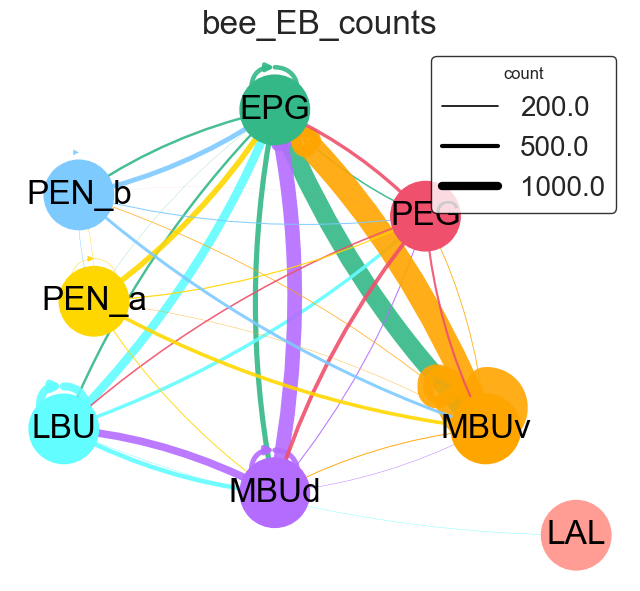

Plot saved: D:\Github\Sayre_et_al_2026_dev\connectome_analysis\code\analysis\../../results\fly_EB_bee-ROI_counts.pdf


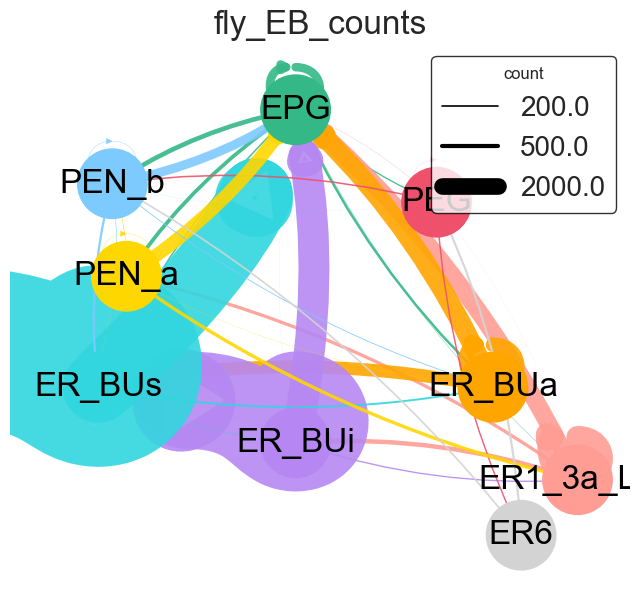

In [43]:
eb_fig_size=(8,7)

draw_connectivity_graph(bg, grouping='by_type', conn_type='count', node_layout=type_EB_layout, figsize=eb_fig_size,
                        width_multiplier=0.006, edge_alpha=0.9, color_dict=color_dict_type, title='bee_EB_counts', 
                        filename=f'bee_EB_node_graph_counts.pdf')

draw_connectivity_graph(fg, grouping='by_type', conn_type='count', node_layout=type_EB_layout, figsize=eb_fig_size,
                        width_multiplier=0.006, edge_alpha=0.9, color_dict=color_dict_type, title='fly_EB_counts', 
                        filename=f'fly_EB_bee-ROI_counts.pdf')

### fig 2g. ER -> ER adj matrix

Plot saved: D:\Github\Sayre_et_al_2026_dev\connectome_analysis\code\analysis\../../results\bee_ER-to-ER_adj_matrix_14-09-26.pdf


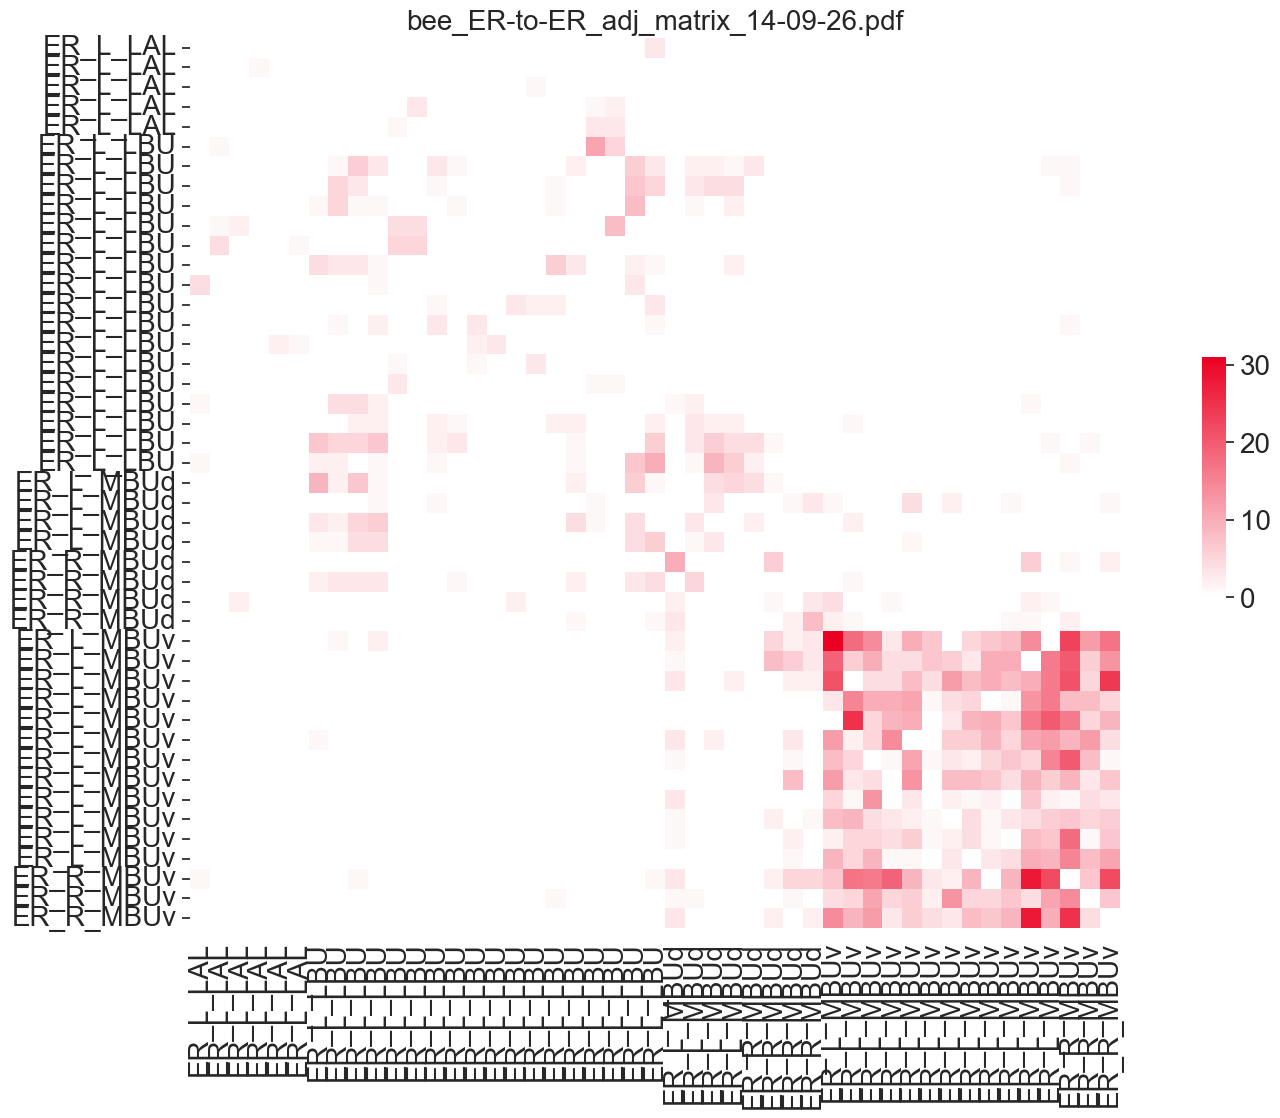

In [13]:
# ER to ER neurons
bee_adj = eb_all_bee[eb_all_bee['type_pre_col'].str.contains(r'ER', na = False) & 
          eb_all_bee['type_post_col'].str.contains(r'ER', na = False)]

to_remove = [ # incomplete neurons
    "ER_L_MBUv_125291",
    "ER_L_MBUv_141300",
    "ER_L_LBU_142037",
]

mask = bee_adj["pre_name"].isin(to_remove) | bee_adj["post_name"].isin(to_remove)

bee_adj = bee_adj[~mask].copy()

bee_adj = bee_adj.groupby(['pre_name','post_name'])['count'].sum().reset_index()

fig_name = f"bee_ER-to-ER_adj_matrix_{today}.pdf"

# coltype = prep_adj(bee_adj)
coltype = prep_adj(
    bee_adj,
    sort_mode="er_first",
    use="name",
    cluster_within_group=True,
    cluster_group_fn=er_group_label,
    cluster_axis="both",      # or "rows" / "columns"
    cluster_method="average",
    cluster_metric="euclidean",
)

# simplify neuron names (remove skid)
coltype.index = coltype.index.to_series().str.replace(r'_\d+$', '', regex=True)
coltype.columns = coltype.columns.to_series().str.replace(r'_\d+$', '', regex=True)

plot_adj(coltype, fig_name=fig_name, colormap="reds_white")

### fig 2h. ER -> columnar neuron adj matrix

Plot saved: D:\Github\Sayre_et_al_2026_dev\connectome_analysis\code\analysis\../../results\bee_ER-to-col_adj_matrix_14-09-26.pdf


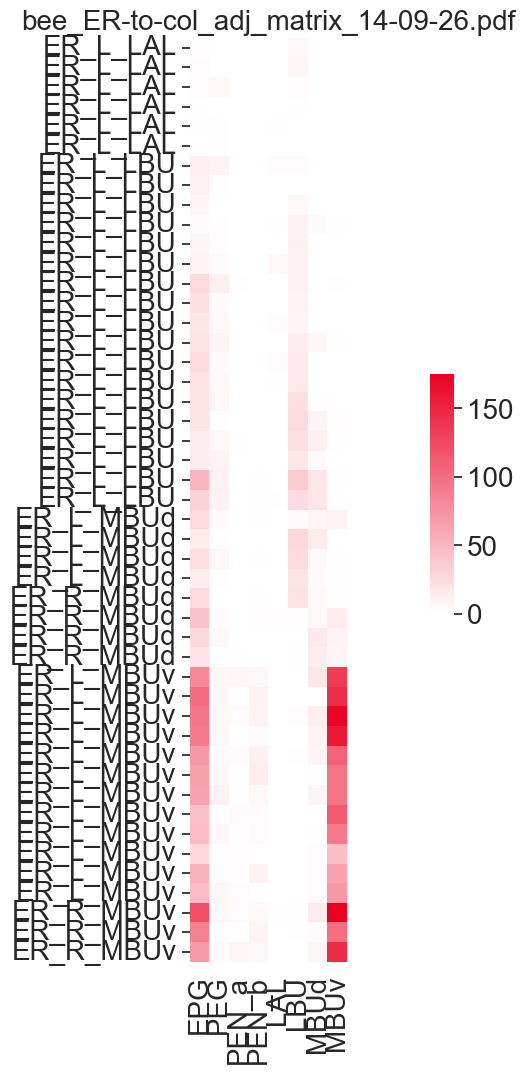

In [14]:
# ER to columnar  neurons
bee_adj = eb_all_bee[eb_all_bee['type_pre_col'].str.contains(r'ER', na = False) & 
          eb_all_bee['type_post_col'].str.contains(r'ER|EPG|PEG|PEN', na = False)]

bee_adj = bee_adj.groupby(['pre_name','type_post'])['count'].sum().reset_index()

to_remove = [ # incomplete neurons
    "ER_L_MBUv_125291",
    "ER_L_MBUv_141300",
    "ER_L_LBU_142037",
]

mask = bee_adj["pre_name"].isin(to_remove)

bee_adj = bee_adj[~mask].copy()


# coltype = prep_adj(bee_adj)
coltype = prep_adj(
    bee_adj,
    sort_mode="er_first",
    use="auto",
    cluster_within_group=True,
    cluster_group_fn=er_group_label,
    cluster_axis="both",      # or "rows" / "columns"
    cluster_method="average",
    cluster_metric="euclidean",
)


fig_name = f"bee_ER-to-col_adj_matrix_{today}.pdf"


coltype.index = coltype.index.to_series().str.replace(r'_\d+$', '', regex=True)

plot_adj(coltype, fig_name=fig_name, colormap="reds_white")

# Figure 4: Ring attractor

### Fig 4c. PB adj matrix

Plot saved: D:\Github\Sayre_et_al_2026_dev\connectome_analysis\code\analysis\../../results\bee_PB_adj_matrix_14-09-26.pdf


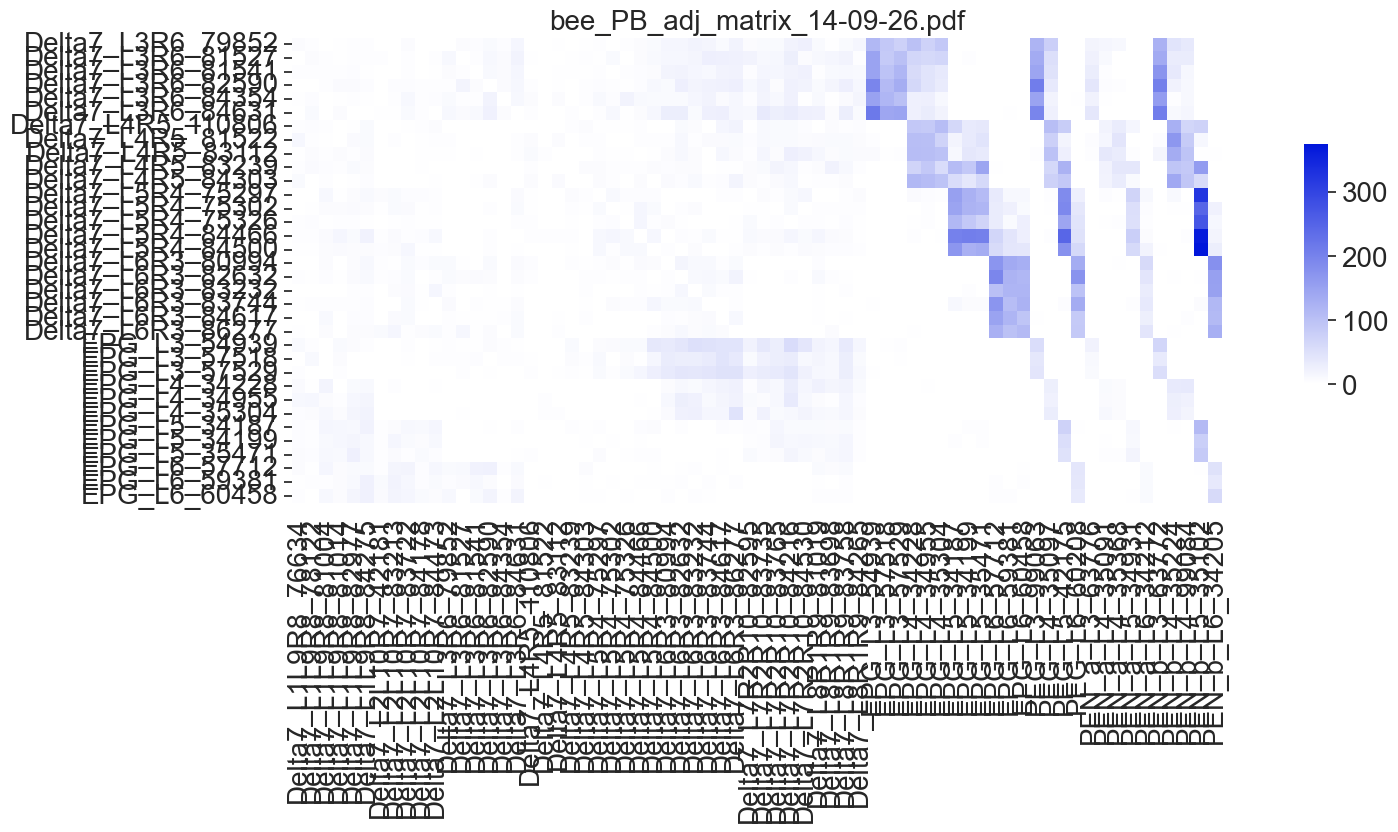

In [15]:
bee_adj = pb_bee.copy()

# Delta7s with outputs in L1, L2 and L7, L8, and L9 are outside PB ROI and PEG only has a few pre-synapses, these get removed
# PEN and PEG don't have PB outputs to any of these cell types, so also removed for space
bee_adj= bee_adj[~pb_bee['type_pre_col'].str.contains(r'Delta7_L1|Delta7_L2|Delta7_L7|Delta7_L8|Delta7_L9|PEG|PEN', regex=True)]

                   
# bee_adj = bee_adj[bee_adj['type_pre_col'].str.contains(r'Delta7', na = False) & bee_adj['type_post_col'].str.contains(r'Delta7', na = False)]

# bee_adj = bee_adj.groupby(['type_pre_col','type_post_col'])['count'].sum().reset_index()

fig_name = f"bee_PB_adj_matrix_{today}.pdf"

coltype = prep_adj(bee_adj)

# coltype.index = coltype.index.to_series().str.replace(r'_\d+$', '', regex=True)

plot_adj(coltype, fig_name=fig_name)

### Fig. 4d. type level PB connectivity graph

Plot saved: D:\Github\Sayre_et_al_2026_dev\connectome_analysis\code\analysis\../../results\bee_PB_node_graph_counts.pdf


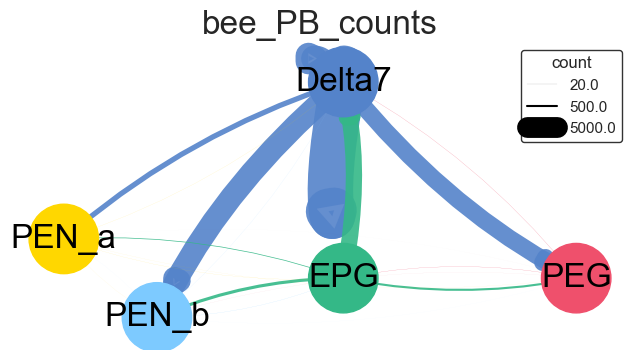

Plot saved: D:\Github\Sayre_et_al_2026_dev\connectome_analysis\code\analysis\../../results\fly_PB_node_graph_counts.pdf


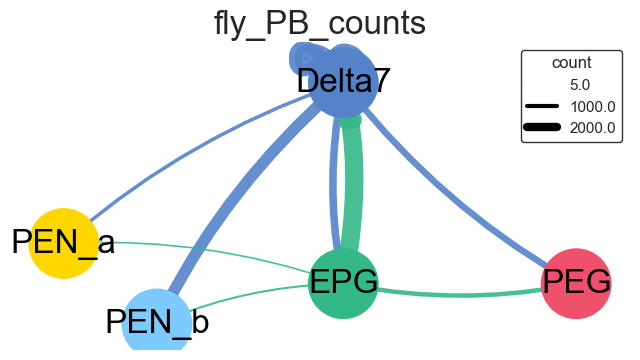

In [16]:
fc = pb_fly.copy()
fc = fc.replace({'EPGt': 'EPG'}, regex=True)
fg = fc.groupby(['type_pre', 'type_post'])['count'].sum().reset_index()

bc = pb_bee.copy()
bc = bc.replace({'EPGt': 'EPG'}, regex=True)
bg = bc.groupby(['type_pre', 'type_post'])['count'].sum().reset_index()


fig_size=(8,4)


draw_connectivity_graph(bg, grouping='by_type', conn_type='count', node_layout=type_PB_layout, figsize=fig_size,
                        width_multiplier=0.003, edge_alpha=0.9, color_dict=color_dict_type, title='bee_PB_counts', 
                        filename=f'bee_PB_node_graph_counts.pdf', sqrt_edges=False)

draw_connectivity_graph(fg, grouping='by_type', conn_type='count', node_layout=type_PB_layout, figsize=fig_size,
                         width_multiplier=0.003, edge_alpha=0.9, color_dict=color_dict_type, title='fly_PB_counts', 
                         filename=f'fly_PB_node_graph_counts.pdf', sqrt_edges=False)

# draw_connectivity_graph(fg, grouping='by_type', conn_type='count', node_layout=type_PB_layout, figsize=fig_size,
#                         width_multiplier=0.002, edge_alpha=0.9, color_dict=color_dict_type, title='fly_PB_counts', 
#                         filename=f'fly_PB_node_graph_counts.pdf', sqrt_edges=False)

Saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\fig3_pb_difference_05-09-26.pdf


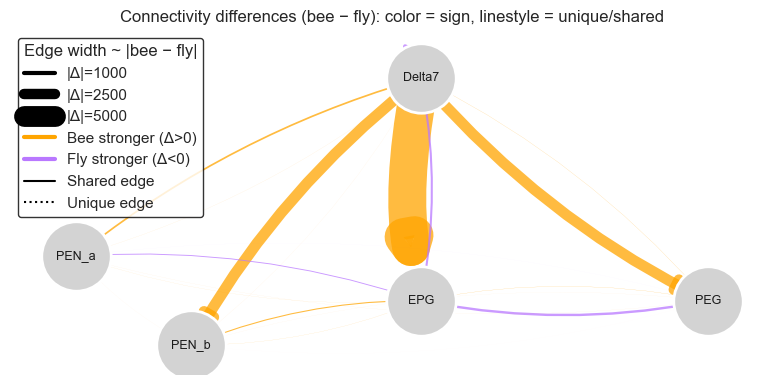

In [15]:
# bee - fly difference conn graph
bee_connections = set(zip(bg['type_pre'], bg['type_post']))
fly_connections = set(zip(fg['type_pre'], fg['type_post']))

bee_only_connections = bee_connections - fly_connections
fly_only_connections = fly_connections - bee_connections
shared_connections   = bee_connections & fly_connections  # optional but handy


# Matrices + diff
bee_matrix = bg.pivot_table(index='type_pre', columns='type_post', values='count', fill_value=0)
fly_matrix = fg.pivot_table(index='type_pre', columns='type_post', values='count', fill_value=0)

all_pre_neurons  = sorted(set(bee_matrix.index).union(fly_matrix.index))
all_post_neurons = sorted(set(bee_matrix.columns).union(fly_matrix.columns))

bee_matrix = bee_matrix.reindex(index=all_pre_neurons, columns=all_post_neurons, fill_value=0)
fly_matrix = fly_matrix.reindex(index=all_pre_neurons, columns=all_post_neurons, fill_value=0)

diff_matrix = bee_matrix - fly_matrix  # bee - fly


# Graph from diff
G = nx.DiGraph()
for pre in diff_matrix.index:
    for post in diff_matrix.columns:
        val = diff_matrix.loc[pre, post]
        if val != 0:
            G.add_edge(pre, post, weight=float(val))


width_multiplier = 0.003
bee_stronger_color = '#FFA500'  # orange
fly_stronger_color = '#b978ff'  # purple

def edge_color_from_weight(w):
    return bee_stronger_color if w > 0 else fly_stronger_color

def edge_style_from_presence(u, v):
    # dotted if unique to either species, solid if shared
    return 'dotted' if ((u, v) in bee_only_connections or (u, v) in fly_only_connections) else 'solid'

# split edges into solid vs dotted for separate draw calls
solid_edges  = []
dotted_edges = []
for u, v in G.edges():
    if edge_style_from_presence(u, v) == 'solid':
        solid_edges.append((u, v))
    else:
        dotted_edges.append((u, v))

# precompute widths/colors in matching order
solid_widths  = [abs(G[u][v]['weight']) * width_multiplier for u, v in solid_edges]
solid_colors  = [edge_color_from_weight(G[u][v]['weight']) for u, v in solid_edges]

dotted_widths = [abs(G[u][v]['weight']) * width_multiplier for u, v in dotted_edges]
dotted_colors = [edge_color_from_weight(G[u][v]['weight']) for u, v in dotted_edges]


# Plot

plt.figure(figsize=(8, 4), facecolor='white')

nx.draw_networkx_nodes(
    G, type_PB_layout,
    node_size=2500,
    node_color='lightGrey',
    linewidths=2.0,
    edgecolors='white'
)
nx.draw_networkx_labels(G, type_PB_layout, font_size=9)

# Shared (solid) edges
nx.draw_networkx_edges(
    G, type_PB_layout,
    edgelist=solid_edges,
    edge_color=solid_colors,
    connectionstyle="arc3,rad=0.1",
    width=solid_widths,
    style='solid',
    arrowsize=20,
    alpha=0.75
)

# Unique (dotted) edges
nx.draw_networkx_edges(
    G, type_PB_layout,
    edgelist=dotted_edges,
    edge_color=dotted_colors,
    connectionstyle="arc3,rad=0.1",
    width=dotted_widths,
    style='dotted',
    arrowsize=20,
    alpha=0.75
)


# Legend
example_abs_diffs = [1000, 2500, 5000]  # pick values meaningful for  scale
legend_lines = [
    mlines.Line2D([], [], linewidth=w * width_multiplier, color='black', label=f'|Δ|={w}')
    for w in example_abs_diffs
]
legend_lines += [
    mlines.Line2D([], [], color=bee_stronger_color, linewidth=3, label='Bee stronger (Δ>0)'),
    mlines.Line2D([], [], color=fly_stronger_color, linewidth=3, label='Fly stronger (Δ<0)'),
    mlines.Line2D([], [], linestyle='solid',  color='black', label='Shared edge'),
    mlines.Line2D([], [], linestyle='dotted', color='black', label='Unique edge'),
]

plt.legend(
    handles=legend_lines,
    title="Edge width ~ |bee − fly|",
    loc="upper left",
    frameon=True,
    edgecolor="black",
    facecolor="white"
)

plt.title("Connectivity differences (bee − fly): color = sign, linestyle = unique/shared")
plt.axis('off')
plt.tight_layout()

fig_name = f"fig3_pb_difference_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)

plt.savefig(
    file_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0
)

print(f"Saved: {file_path}")
plt.show()


### Fig. 4e delta7 col_type node graph 

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\bee_delta7_node_graph.pdf


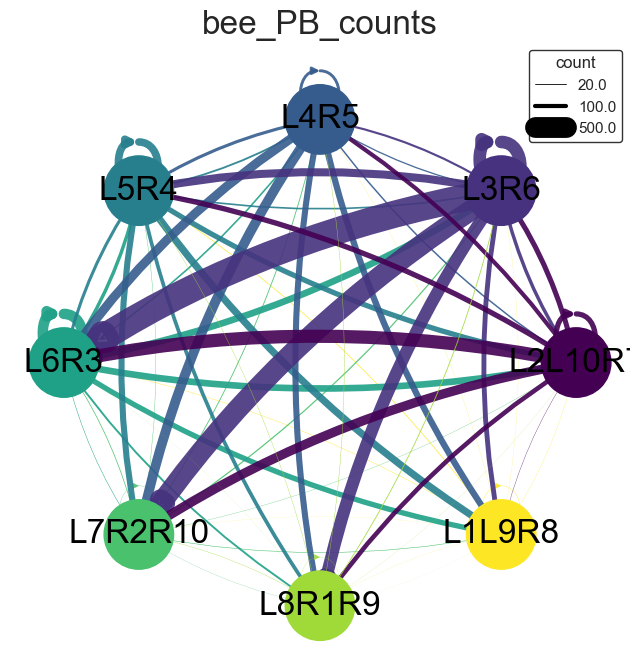

In [16]:
bc = pb_bee.copy()
bc = bc[bc['type_pre_col'].str.contains('Delta7') & bc['type_post_col'].str.contains('Delta7')]
bg = bc.groupby(['type_pre_col', 'type_post_col'])['count'].sum().reset_index()
bg_fullname = bg.copy()
bg.replace({'Delta7_': ''}, regex=True, inplace=True)

bg.replace({'L9L1R8': ''}, regex=True, inplace=True)

delta7_nodes = [
    "L1L9R8",
    "L2L10R7",
    "L3R6",
    "L4R5",
    "L5R4",
    "L6R3",
    "L7R2R10",
    "L8R1R9"
]

bg.sort_values('type_post_col', inplace=True)

delta7_color_order = [
    "L2L10R7",
    "L3R6",
    "L4R5",
    "L5R4",
    "L6R3",
    "L7R2R10",
    "L8R1R9",
    "L1L9R8"
]

cmap = plt.get_cmap("viridis")

delta7_colors = {
    node: cmap(i / (len(delta7_color_order) - 1))
    for i, node in enumerate(delta7_color_order)
}

# evenly spaced around a circle
angles = np.linspace(0, 2*np.pi, len(delta7_nodes), endpoint=False)

# rotation so a chosen node starts where wanted
rotation = -np.pi/4 

delta7_layout = {
    node: (np.cos(a + rotation), np.sin(a + rotation))
    for node, a in zip(delta7_nodes, angles)
}

draw_connectivity_graph(
    bg,
    grouping='by_type_col',
    conn_type='count',
    node_layout=delta7_layout,
    figsize=(8, 8),
    width_multiplier=0.03,
    legend_weights=[0.4, 0.7, 0.99],
    edge_alpha=0.9,
    color_dict=delta7_colors,
    title='bee_PB_counts',
    filename='bee_delta7_node_graph.pdf',
    sqrt_edges=False
)

### Fig. 4f Delta7 / EPG distribution shape analysis

In [17]:
### user_input (either Delta7 or EPG)
neuron_type = os.environ.get("NEURON_TYPE", "EPG")

##########
if neuron_type == "Delta7":
    shifts = {"Delta7_L3R6": 3, "Delta7_L4R5": 4, "Delta7_L5R4": 5, "Delta7_L6R3": 6}
elif neuron_type == "EPG":
    shifts = {"EPG_L3": 2, "EPG_L4": 3, "EPG_L5": 4, "EPG_L6": 5} # the global shift is arbitrary (just centering the max amplitude of the sin distribution)

bee_simp = pb_bee.copy()

if neuron_type == "Delta7":
    bee_simp = bee_simp[bee_simp['type_pre_col'].str.contains(r'Delta7', na = False) & bee_simp['type_post_col'].str.contains(r'Delta7', na = False)]
    # Delta7 L2 and L7 are outside PB ROI and PEG only has a few pre-synapses, these get removed
    bee_simp= bee_simp[~bee_simp['type_pre_col'].str.contains(r'Delta7_L1L9R8|Delta7_L2L7R10|Delta7_L2L1|Delta7_L7R2R10|Delta7_L8R1R9', regex=True)]
elif neuron_type == "EPG":
    bee_simp = bee_simp[bee_simp['type_pre_col'].str.contains(r'EPG_L3|EPG_L4|EPG_L5|EPG_L6', na = False) & 
    bee_simp['type_post_col'].str.contains(r'Delta7', na = False)]

bee_adj = bee_simp.copy()
bee_adj = prep_adj(bee_adj, use='name')

bee_adj.index = bee_adj.index.to_series().str.replace(r'_\d+$', '', regex=True)
bee_adj.columns = bee_adj.columns.to_series().str.replace(r'_\d+$', '', regex=True)

##########
fly_simp = pb_fly.copy()

# group Delta7_L7R3 with Delta7_L6R3 
canon_map = {
    r'Delta7_L7R3(?=(_|$))': 'Delta7_L7R2',
    r'Delta7_L6R4(?=(_|$))': 'Delta7_L6R3',
    r'Delta7_L4R6(?=(_|$))': 'Delta7_L4R5',
}

fly_simp = fly_simp.replace(canon_map, regex=True)

if neuron_type == "Delta7":
    fly_simp = fly_simp[fly_simp['type_pre_col'].str.contains(r'Delta7', na = False) & fly_simp['type_post_col'].str.contains(r'Delta7', na = False)]
    # Delta7 L2 and L7 are outside PB ROI and PEG only has a few pre-synapses, these get removed
    fly_simp= fly_simp[~fly_simp['type_pre_col'].str.contains(r'Delta7_L2L1|Delta7_L7R2|Delta7_L1L9R8|Delta7_L2R7|Delta7_L7R2|Delta7_L7R3|Delta7_L8R1R9', regex=True)]
elif neuron_type == "EPG":
    fly_simp = fly_simp[fly_simp['type_pre_col'].str.contains(r'EPG_L3|EPG_L4|EPG_L5|EPG_L6', na = False) & 
    fly_simp['type_post_col'].str.contains(r'Delta7', na = False)]
    
fly_adj = fly_simp.copy()
fly_adj = prep_adj(fly_adj)

fly_adj.index = fly_adj.index.to_series().str.replace(r'_\d+$', '', regex=True)
fly_adj.columns = fly_adj.columns.to_series().str.replace(r'_\d+$', '', regex=True)

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\bee_PB_adj_matrix_EPG-D7_05-09-26.pdf


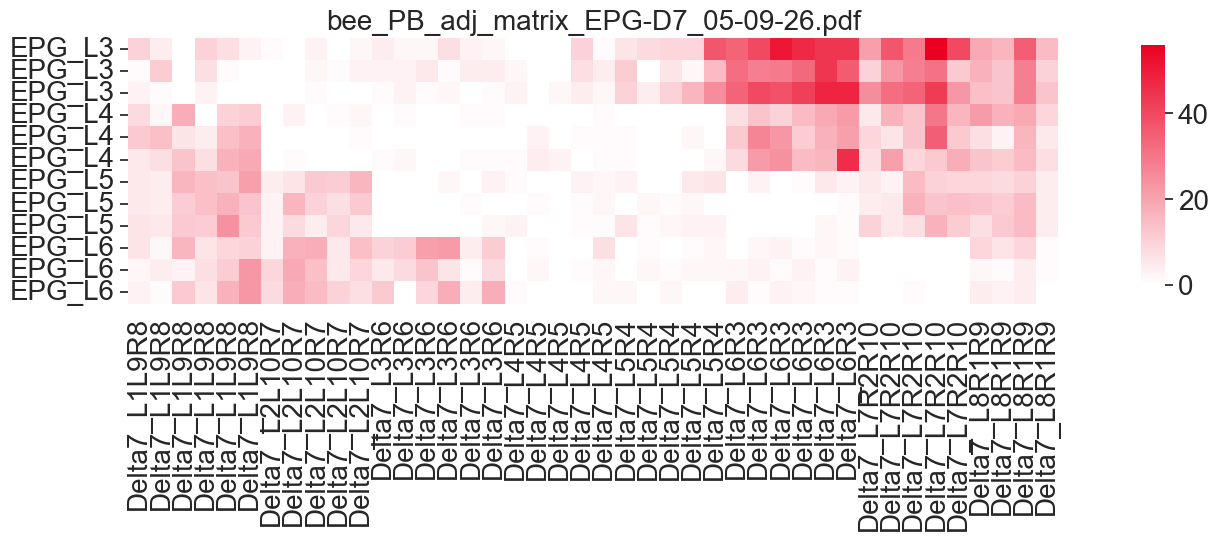

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\bee_PB_shifted_adj_matrix_05-09-26.pdf


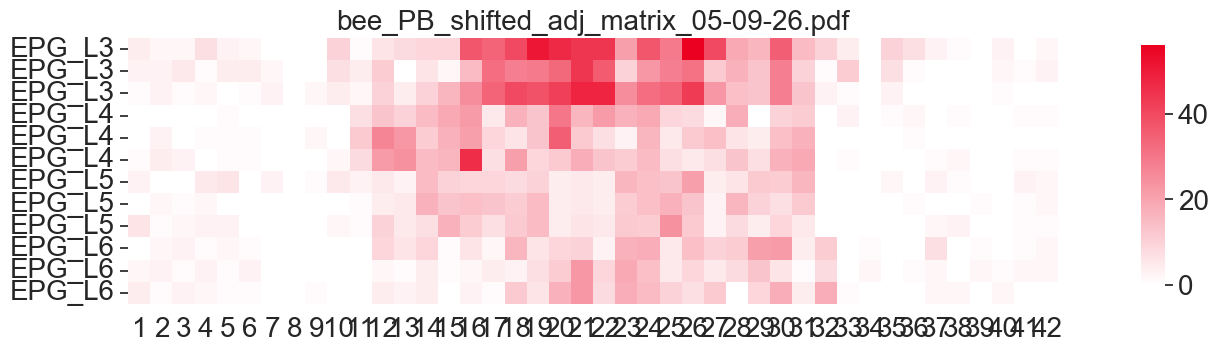

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\bee_PB_shifted_smooth_adj_matrix_05-09-26.pdf


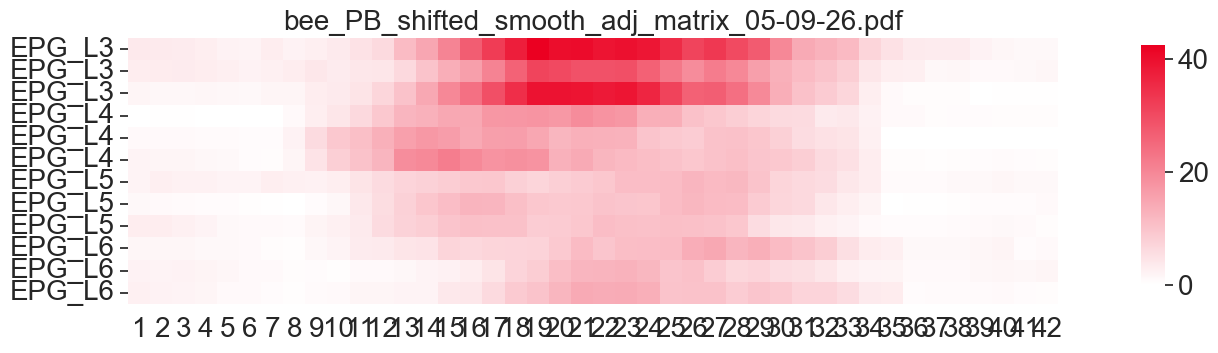

In [18]:
# sinusoidal output analysis
    
df = bee_adj.copy()
df.index = df.index.to_series().str.replace(r'_\d+$', '', regex=True)
df.columns = df.columns.to_series().str.replace(r'_\d+$', '', regex=True)

# define column type for each column
col_type = df.columns.to_series().str.replace(r'_\d+$', '', regex=True)

# column blocks in current order
types_in_order = pd.Index(col_type).unique().tolist()
blocks = [np.where(col_type.to_numpy() == t)[0] for t in types_in_order]


# IMPORTANT: don’t destroy uniqueness of the row index; use a separate series for matching
row_type = df.index.to_series().str.replace(r'_\d+$', '', regex=True)

df_shifted = df.copy()

for t, k in shifts.items():
    rows = row_type == t
    if not rows.any():
        continue

    # rotate the *blocks* list by k (left shift)
    new_blocks = blocks[k:] + blocks[:k]
    new_col_idx = np.concatenate(new_blocks)

    # reorder values within those rows accordingly
    df_shifted.loc[rows, :] = df_shifted.loc[rows, :].to_numpy()[:, new_col_idx]

# rename columns to 1..N (optional)
df_shifted.columns = range(1, df_shifted.shape[1] + 1)

# smooth each row independently along columns (not used for sinusoidal fitting below)
bee_smooth = (
    df_shifted
    .rolling(window=7, axis=1, center=True, min_periods=1)
    .mean()
)

bee_shifted = df_shifted.copy()

bee_figname = f"bee_PB_adj_matrix_EPG-D7_{today}.pdf"
plot_adj(bee_adj, fig_name=bee_figname, colormap="reds_white")
bee_figname = f"bee_PB_shifted_adj_matrix_{today}.pdf"
plot_adj(bee_shifted, fig_name=bee_figname, colormap="reds_white")
bee_figname = f"bee_PB_shifted_smooth_adj_matrix_{today}.pdf"
plot_adj(bee_smooth, fig_name=bee_figname, colormap="reds_white")


Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\fly_PB_adj_matrix_05-09-26.pdf


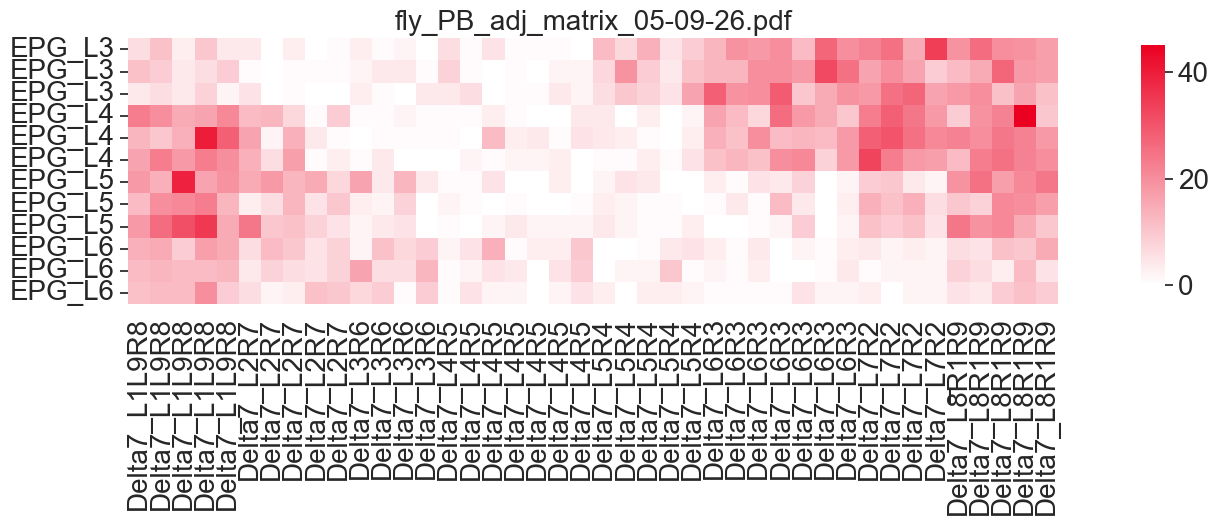

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\fly_PB_shifted_adj_matrix_05-09-26.pdf


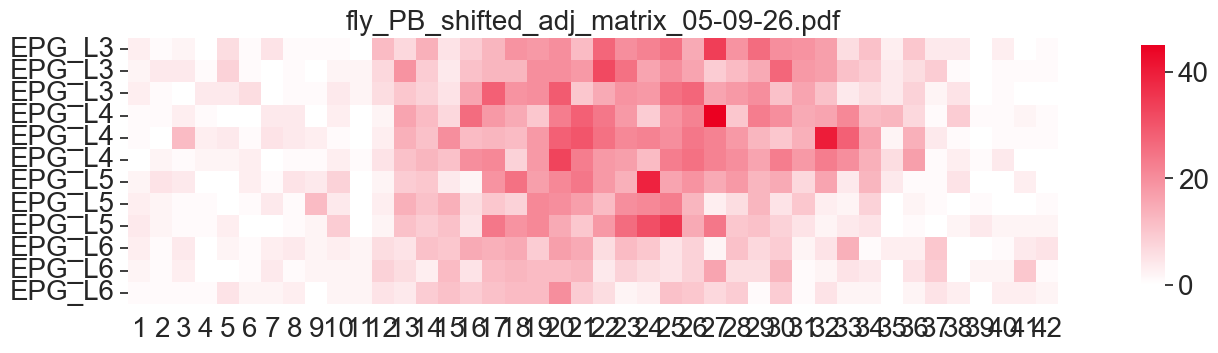

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\fly_PB_shifted_smoothed_adj_matrix_05-09-26.pdf


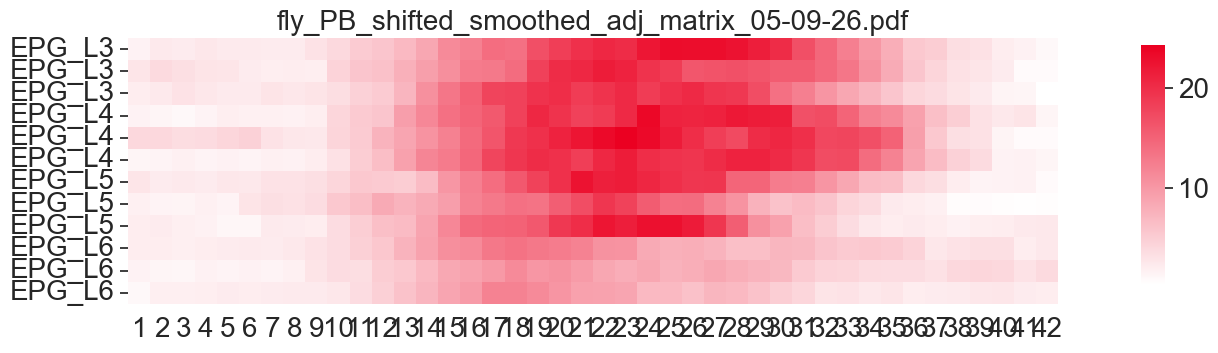

In [19]:
# laterally shifted d7 adj matrix
df = fly_adj.copy()

df.index = df.index.to_series().str.replace(r'_\d+$', '', regex=True)
df.columns = df.columns.to_series().str.replace(r'_\d+$', '', regex=True)

# define column type for each column
col_type = df.columns.to_series().str.replace(r'_\d+$', '', regex=True)

# column blocks in current order
types_in_order = pd.Index(col_type).unique().tolist()
blocks = [np.where(col_type.to_numpy() == t)[0] for t in types_in_order]


# IMPORTANT: don’t destroy uniqueness of the row index; use a separate series for matching
row_type = df.index.to_series().str.replace(r'_\d+$', '', regex=True)

df_shifted = df.copy()

for t, k in shifts.items():
    rows = row_type == t
    if not rows.any():
        continue

    # rotate the *blocks* list by k (left shift)
    new_blocks = blocks[k:] + blocks[:k]
    new_col_idx = np.concatenate(new_blocks)

    # reorder values within those rows accordingly
    df_shifted.loc[rows, :] = df_shifted.loc[rows, :].to_numpy()[:, new_col_idx]

# rename columns to 1..N (optional)
df_shifted.columns = range(1, df_shifted.shape[1] + 1)

# smooth each row independently along columns
fly_smooth = (
    df_shifted
    .rolling(window=7, axis=1, center=True, min_periods=1)
    .mean()
)

fly_shifted = df_shifted.copy()

fly_figname = f"fly_PB_adj_matrix_{today}.pdf"
plot_adj(fly_adj, fig_name=fly_figname, colormap="reds_white")
fly_figname = f"fly_PB_shifted_adj_matrix_{today}.pdf"
plot_adj(fly_shifted, fig_name=fly_figname, colormap="reds_white")
fly_figname = f"fly_PB_shifted_smoothed_adj_matrix_{today}.pdf"
plot_adj(fly_smooth, fig_name=fly_figname, colormap="reds_white")

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\bee_PB_adj_matrix_EPG-pre_05-09-26.pdf


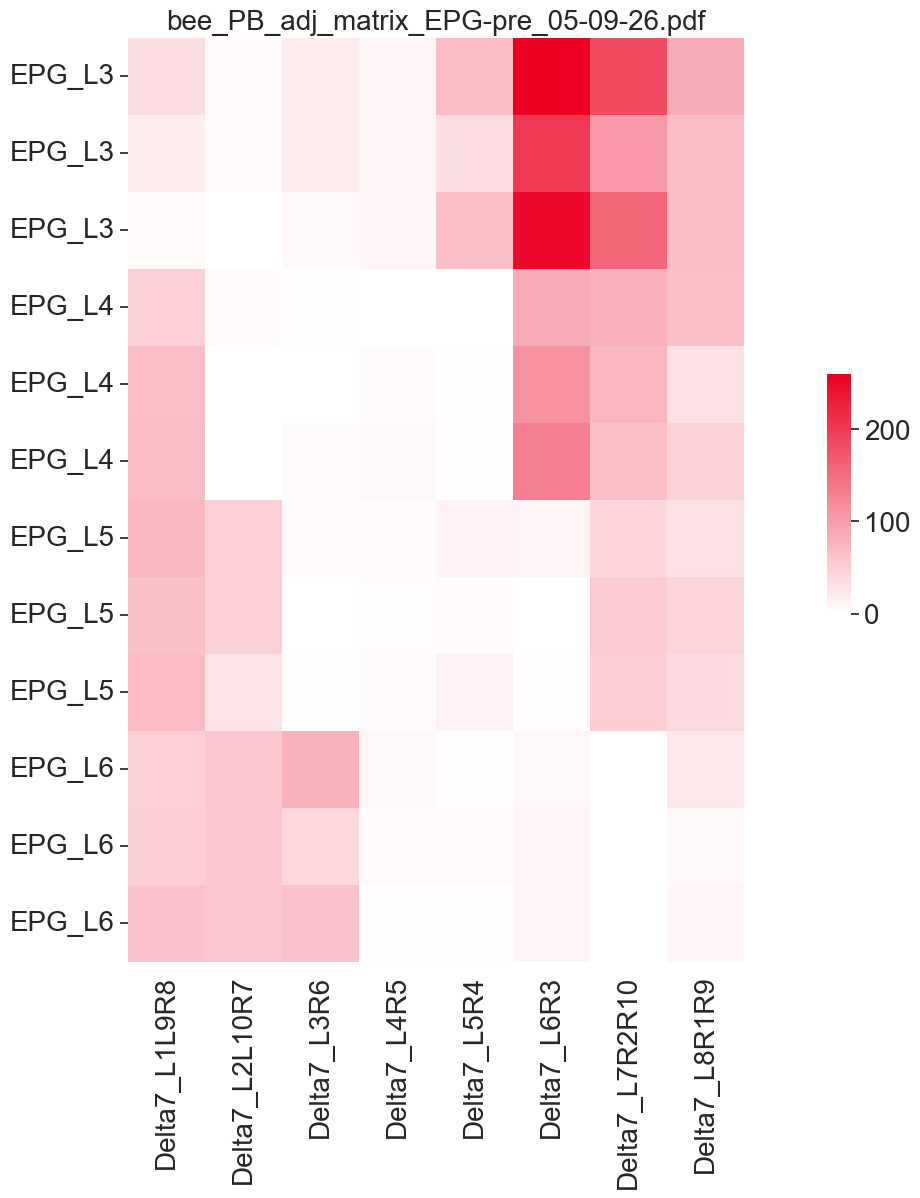

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\bee_PB_shifted_adj_matrix_EPG-pre_05-09-26.pdf


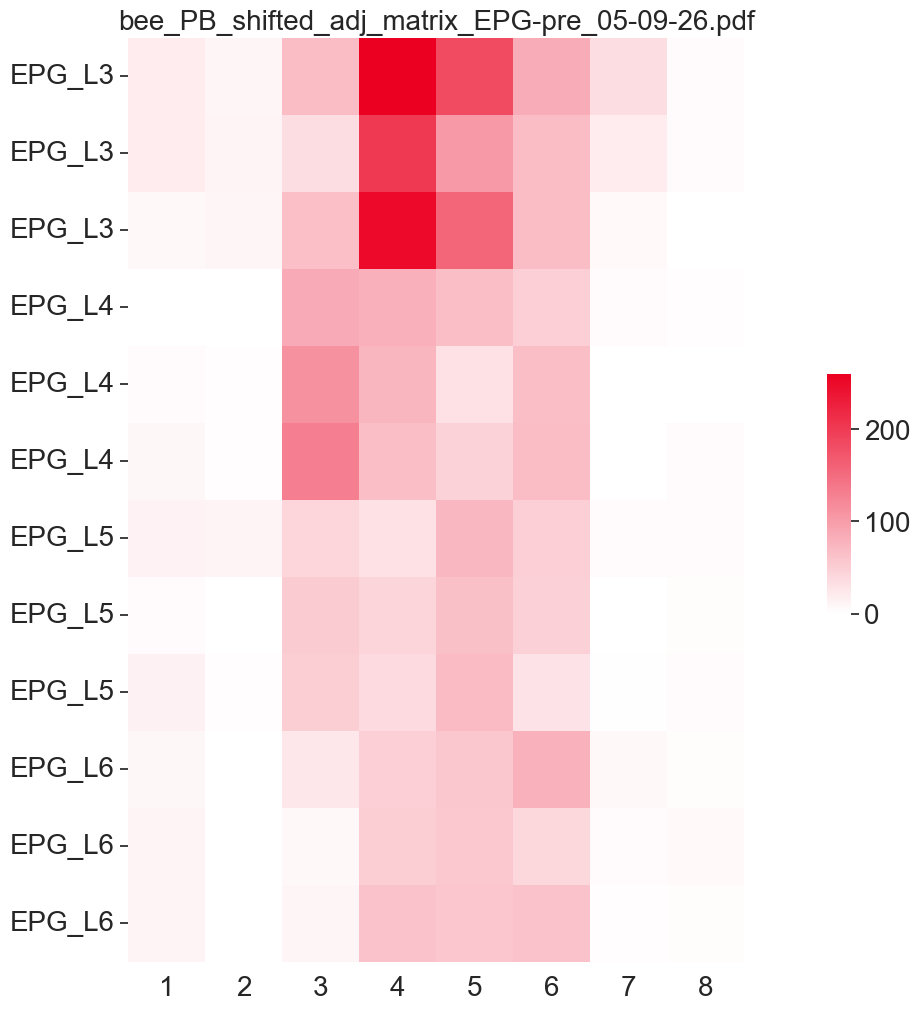

In [20]:
# laterally shifted d7 adj matrix
df = bee_adj.groupby(level=0, axis=1).sum() # group columns and sum
bee_notshifted = df.copy()

df.index = df.index.to_series().str.replace(r'_\d+$', '', regex=True)
df.columns = df.columns.to_series().str.replace(r'_\d+$', '', regex=True)

# define column type for each column
col_type = df.columns.to_series().str.replace(r'_\d+$', '', regex=True)

# column blocks in current order
types_in_order = pd.Index(col_type).unique().tolist()
blocks = [np.where(col_type.to_numpy() == t)[0] for t in types_in_order]


# IMPORTANT: don’t destroy uniqueness of the row index; use a separate series for matching
row_type = df.index.to_series().str.replace(r'_\d+$', '', regex=True)

df_shifted = df.copy()

for t, k in shifts.items():
    rows = row_type == t
    if not rows.any():
        continue

    # rotate the *blocks* list by k (left shift)
    new_blocks = blocks[k:] + blocks[:k]
    new_col_idx = np.concatenate(new_blocks)

    # reorder values within those rows accordingly
    df_shifted.loc[rows, :] = df_shifted.loc[rows, :].to_numpy()[:, new_col_idx]

# rename columns to 1..N (optional)
df_shifted.columns = range(1, df_shifted.shape[1] + 1)


bee_shifted = df_shifted.copy()


bee_figname = f"bee_PB_adj_matrix_{neuron_type}-pre_{today}.pdf"
plot_adj(bee_notshifted, fig_name=bee_figname, colormap="reds_white")
bee_figname = f"bee_PB_shifted_adj_matrix_{neuron_type}-pre_{today}.pdf"
plot_adj(bee_shifted, fig_name=bee_figname, colormap="reds_white")
# bee_figname = f"bee_PB_shifted_smooth_adj_matrix_{neuron_type}-pre_{today}.pdf"
# plot_adj(bee_smooth, fig_name=bee_figname, colormap="reds_white")


Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\fly_PB_adj_matrix_EPG-pre_05-09-26.pdf


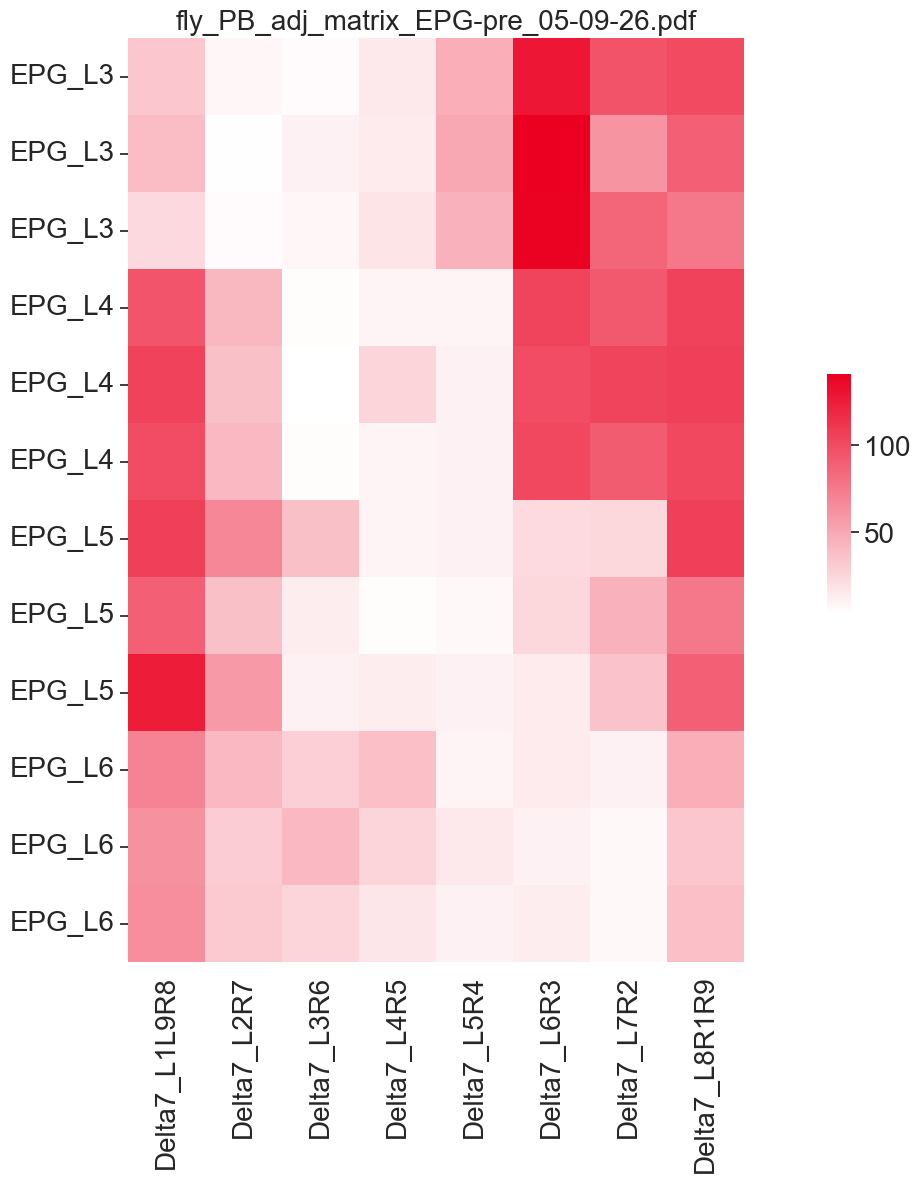

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\fly_PB_shifted_adj_matrix_EPG-pre_05-09-26.pdf


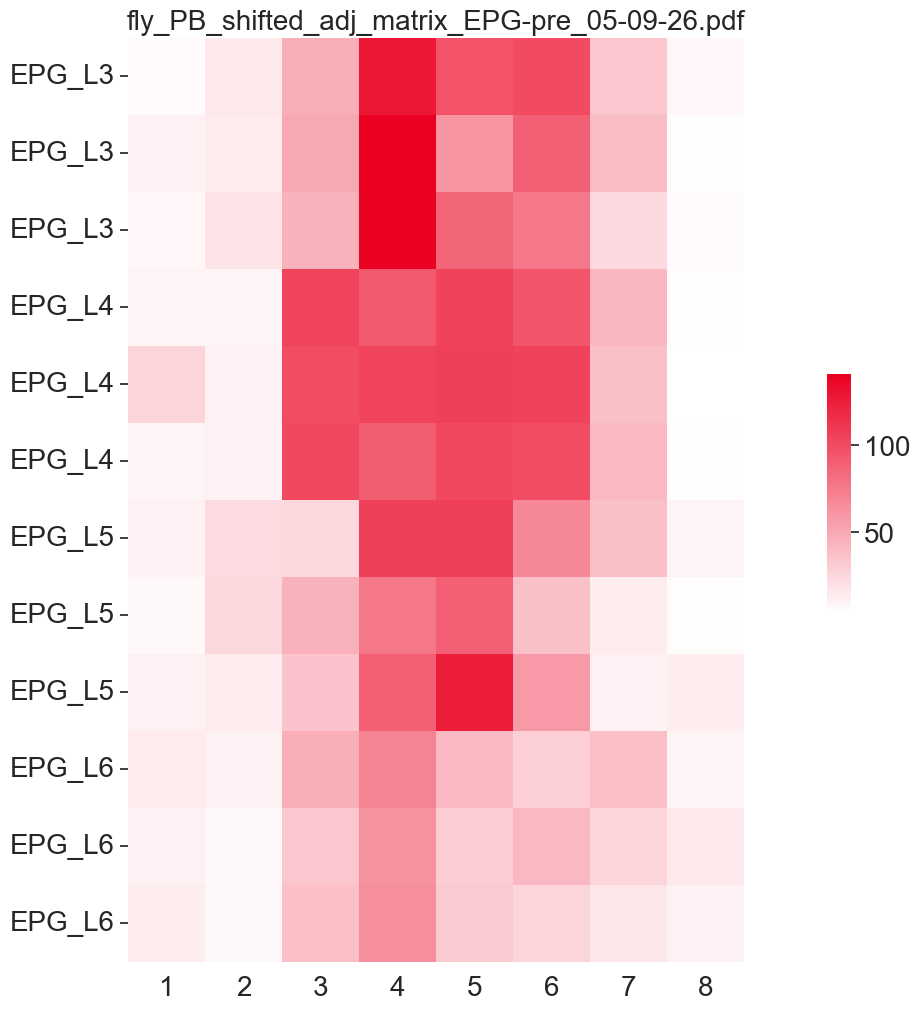

In [21]:
# laterally shifted d7 adj matrix
df = fly_adj.groupby(level=0, axis=1).sum() # group columns and sum
fly_notshifted = df.copy()

df.index = df.index.to_series().str.replace(r'_\d+$', '', regex=True)
df.columns = df.columns.to_series().str.replace(r'_\d+$', '', regex=True)

# define column type for each column
col_type = df.columns.to_series().str.replace(r'_\d+$', '', regex=True)

# column blocks in current order
types_in_order = pd.Index(col_type).unique().tolist()
blocks = [np.where(col_type.to_numpy() == t)[0] for t in types_in_order]

# IMPORTANT: don’t destroy uniqueness of the row index; use a separate series for matching
row_type = df.index.to_series().str.replace(r'_\d+$', '', regex=True)

df_shifted = df.copy()

for t, k in shifts.items():
    rows = row_type == t
    if not rows.any():
        continue

    # rotate the *blocks* list by k (left shift)
    new_blocks = blocks[k:] + blocks[:k]
    new_col_idx = np.concatenate(new_blocks)

    # reorder values within those rows accordingly
    df_shifted.loc[rows, :] = df_shifted.loc[rows, :].to_numpy()[:, new_col_idx]

# rename columns to 1..N (optional)
df_shifted.columns = range(1, df_shifted.shape[1] + 1)

fly_shifted = df_shifted.copy()

fly_figname = f"fly_PB_adj_matrix_{neuron_type}-pre_{today}.pdf"
plot_adj(fly_notshifted, fig_name=fly_figname, colormap="reds_white")
fly_figname = f"fly_PB_shifted_adj_matrix_{neuron_type}-pre_{today}.pdf"
plot_adj(fly_shifted, fig_name=fly_figname, colormap="reds_white")
# fly_figname = f"fly_PB_shifted_smoothed_adj_matrix_{neuron_type}-pre_{today}.pdf"
# plot_adj(fly_smooth, fig_name=fly_figname, colormap="reds_white")

In [22]:
'''sinewave overlay bar plot for D7
-> sine fit is restricted to columns 1-7'''

if neuron_type == "Delta7":    
    def sine_model(x, A, phi, C, period):
        return A * np.sin(2 * np.pi * x / period + phi) + C
    
    def fit_sine_and_r2(x, y, period=None):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
    
        if period is None:
            period = len(x)
    
        p0 = [
            (y.max() - y.min()) / 2,
            0.0,
            y.mean(),
        ]
    
        def model_for_fit(x, A, phi, C):
            return sine_model(x, A, phi, C, period)
    
        popt, _ = curve_fit(model_for_fit, x, y, p0=p0)
        y_hat = model_for_fit(x, *popt)
    
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    
        return popt, y_hat, r2, period
    
    def col_summary(df, err="sem"):
        mean = df.mean(axis=0)
    
        if err == "sd":
            e = df.std(axis=0, ddof=1)
        elif err == "sem":
            n = df.notna().sum(axis=0)
            e = df.std(axis=0, ddof=1) / np.sqrt(n)
        else:
            raise ValueError("err must be 'sem' or 'sd'")
    
        return pd.DataFrame({"mean": mean, "err": e})
    
    # summaries
    bee_sum = col_summary(bee_shifted, err="sem")
    fly_sum = col_summary(fly_shifted, err="sem")
    
    # align columns just in case
    common_cols = bee_sum.index.intersection(fly_sum.index)
    bee_sum = bee_sum.loc[common_cols]
    fly_sum = fly_sum.loc[common_cols]
    
    # full bar positions: keep all 8 columns
    x_all = np.arange(len(common_cols))
    
    bee_y = bee_sum["mean"].to_numpy()
    fly_y = fly_sum["mean"].to_numpy()
    
    # fit only columns 1-7 (indices 0..6)
    fit_mask = x_all < 7
    x_fit = x_all[fit_mask]
    bee_y_fit = bee_y[fit_mask]
    fly_y_fit = fly_y[fit_mask]
    
    # fit sine only on first 7 columns
    bee_params, bee_fit, bee_r2, _ = fit_sine_and_r2(x_fit, bee_y_fit, period=len(x_fit))
    fly_params, fly_fit, fly_r2, _ = fit_sine_and_r2(x_fit, fly_y_fit, period=len(x_fit))
    
    print(f"Bee R² (cols 1–7) = {bee_r2:.3f}")
    print(f"Fly R² (cols 1–7) = {fly_r2:.3f}")
    
    # --- bar plot ---
    width = 0.42
    fig, ax = plt.subplots(figsize=(14, 4))
    
    ax.bar(
        x_all - width/2,
        bee_y,
        width,
        yerr=bee_sum["err"].to_numpy(),
        capsize=3,
        label="bee",
        color="#FFB00E"
    )
    
    ax.bar(
        x_all + width/2,
        fly_y,
        width,
        yerr=fly_sum["err"].to_numpy(),
        capsize=3,
        label="fly",
        color="#C38AFF"
    )
    
    # plot fitted lines only over columns 1-7
    ax.plot(
        x_fit - width/2,
        bee_fit,
        color="#FFB00E",
        linewidth=2,
        label=f"bee sine (R²={bee_r2:.2f})"
    )
    
    ax.plot(
        x_fit + width/2,
        fly_fit,
        color="#C38AFF",
        linewidth=2,
        label=f"fly sine (R²={fly_r2:.2f})"
    )
    
    ax.set_xticks(x_all)
    ax.set_xticklabels(common_cols)
    ax.set_ylabel("mean synapse count", fontsize=24)
    ax.legend(fontsize=24)
    ax.set_title("Column-averaged adjacency (mean ± SEM)", fontsize=24)
    ax.tick_params(axis="both", labelsize=24)
    ax.set_ylim(bottom=0)
    ax.margins(y=0)
    
    plt.tight_layout()
    
    fig_name = f"sine_reformatting_barplot_fly-bee_{neuron_type}_{today}.pdf"
    file_path = os.path.join(save_dir, fig_name)
    plt.savefig(file_path, bbox_inches="tight", pad_inches=0, format="pdf")
    print(f"Plot saved: {file_path}")
    
    plt.show()

Bee R² = 0.898
Fly R² = 0.952
Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\sine_reformatting_barplot_fly-bee_EPG_05-09-26.pdf


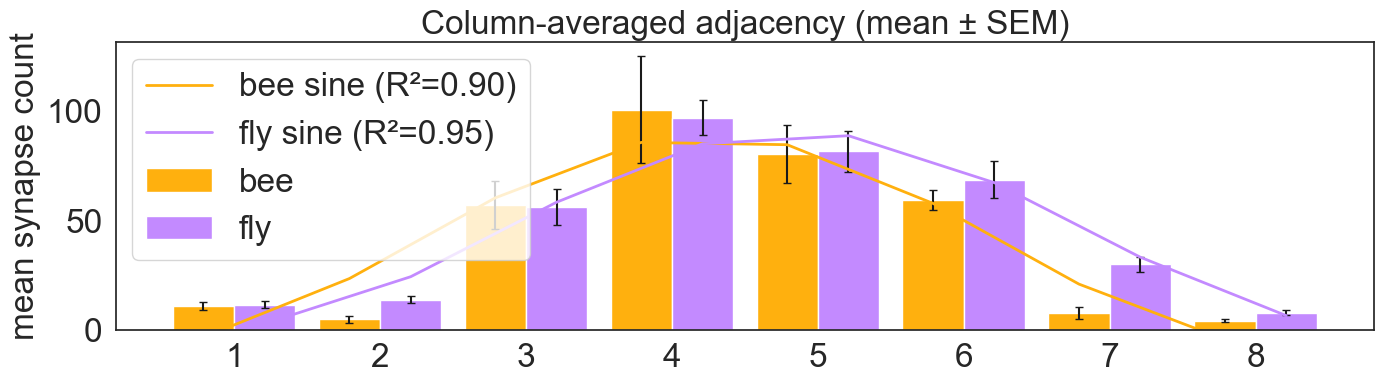

In [23]:
'''sinewave overlay bar plot for EPG
-> sine fitted to all 8 columns'''

if neuron_type == "EPG":
    def sine_model(x, A, phi, C):
        # one full cycle over the domain
        return A * np.sin(2 * np.pi * x / len(x) + phi) + C
    
    def fit_sine_and_r2(y):
        x = np.arange(len(y))
    
        # initial guesses
        p0 = [
            (y.max() - y.min()) / 2,  # A
            0.0,                      # phi
            y.mean()                  # C
        ]
    
        popt, _ = curve_fit(sine_model, x, y, p0=p0)
        y_hat = sine_model(x, *popt)
    
        ss_res = np.sum((y - y_hat)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 1 - ss_res / ss_tot
    
        return popt, y_hat, r2
    
    def col_summary(df, err="sem"):
        """
        Summarize a matrix (rows=observations, cols=positions) into per-column mean + error.
        err: "sem" (default) or "sd"
        """
        mean = df.mean(axis=0)
    
        if err == "sd":
            e = df.std(axis=0, ddof=1)
        elif err == "sem":
            n = df.notna().sum(axis=0)
            e = df.std(axis=0, ddof=1) / np.sqrt(n)
        else:
            raise ValueError("err must be 'sem' or 'sd'")
    
        out = pd.DataFrame({"mean": mean, "err": e})
        return out
    
    # summaries
    bee_sum = col_summary(bee_shifted, err="sem")
    fly_sum = col_summary(fly_shifted, err="sem")
    
    # align columns just in case (important)
    common_cols = bee_sum.index.intersection(fly_sum.index)
    bee_sum = bee_sum.loc[common_cols]
    fly_sum = fly_sum.loc[common_cols]
    
    
    bee_y = bee_sum["mean"].to_numpy()
    fly_y = fly_sum["mean"].to_numpy()
    
    bee_params, bee_fit, bee_r2 = fit_sine_and_r2(bee_y)
    fly_params, fly_fit, fly_r2 = fit_sine_and_r2(fly_y)
    
    print(f"Bee R² = {bee_r2:.3f}")
    print(f"Fly R² = {fly_r2:.3f}")
    
    # summaries
    bee_sum = col_summary(bee_shifted, err="sem")
    fly_sum = col_summary(fly_shifted, err="sem")
    
    # align columns just in case (important)
    common_cols = bee_sum.index.intersection(fly_sum.index)
    bee_sum = bee_sum.loc[common_cols]
    fly_sum = fly_sum.loc[common_cols]
    
    # --- bar plot ---
    x = np.arange(len(common_cols))
    width = 0.42
    
    fig, ax = plt.subplots(figsize=(14, 4))
    
    ax.bar(x - width/2, bee_sum["mean"].to_numpy(), width, yerr=bee_sum["err"].to_numpy(),
           capsize=3, label="bee", color="#FFB00E")
    ax.bar(x + width/2, fly_sum["mean"].to_numpy(), width, yerr=fly_sum["err"].to_numpy(),
           capsize=3, label="fly", color="#C38AFF")
    
    x = np.arange(len(bee_y))
    
    ax.plot(
        x - width/2,
        bee_fit,
        color="#FFB00E",
        linewidth=2,
        label=f"bee sine (R²={bee_r2:.2f})"
    )
    
    ax.plot(
        x + width/2,
        fly_fit,
        color="#C38AFF",
        linewidth=2,
        label=f"fly sine (R²={fly_r2:.2f})"
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(common_cols)
    ax.set_ylabel("mean synapse count", fontsize=24)
    ax.legend(fontsize=24)
    ax.set_title("Column-averaged adjacency (mean ± SEM)", fontsize=24)
    ax.tick_params(axis='both', labelsize=24)
    ax.set_ylim(bottom=0)
    ax.margins(y=0)
    
    plt.tight_layout()
    
    # Construct the filename and save the plot
    fig_name = f"sine_reformatting_barplot_fly-bee_{neuron_type}_{today}.pdf"
    file_path = os.path.join(save_dir, fig_name)
    plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
    print(f"Plot saved: {file_path}")
    
    plt.show()


### Fig. 4g: EB columnar -> EB columnar adj matrix

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\bee_EB_adj_matrix_05-09-26.pdf


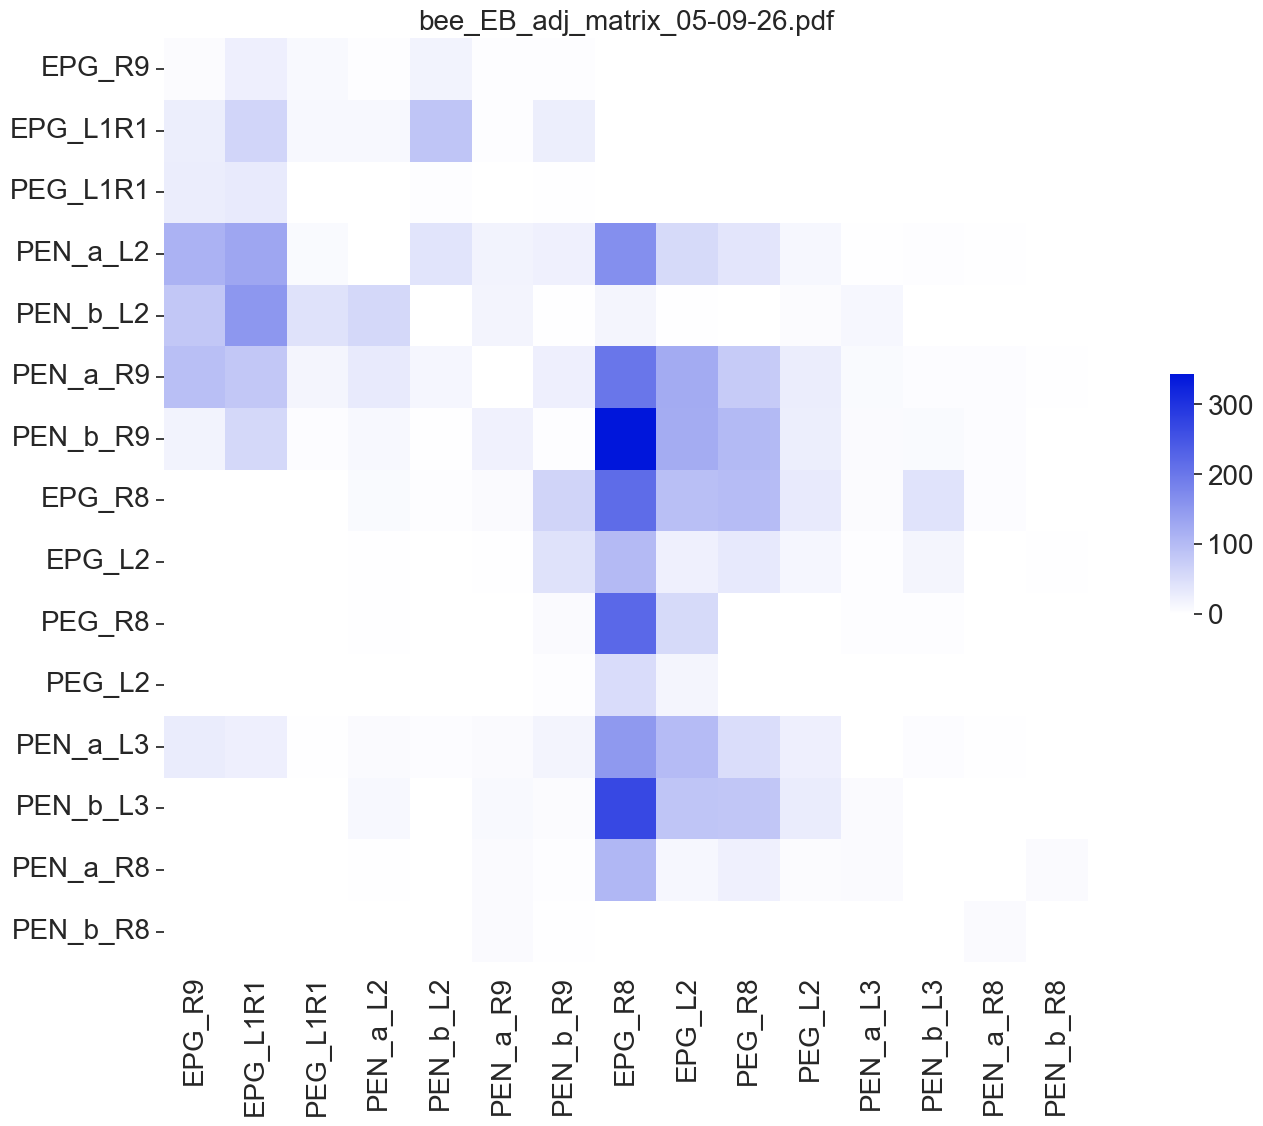

In [24]:
bee_adj = eb_core_bee.copy()

# bee_adj= bee_adj[~(eb_core_bee['type_pre_col'].str.contains(r'Delta7_L2L1|Delta7_L7R2R10|PEG_L3|PEG_L6', regex=True) | 
#                  eb_core_bee['type_post_col'].str.contains(r'Delta7', regex=True))]
# bee_adj= bee_adj[~eb_core_bee['type_pre_col'].str.contains(r'Delta7_L2L1|Delta7_L7R2R10|PEG_L3|PEG_L6', regex=True)] 
                   
# bee_adj = bee_adj[bee_adj['type_pre_col'].str.contains(r'Delta7', na = False) & bee_adj['type_post_col'].str.contains(r'Delta7', na = False)]

bee_adj = bee_adj.groupby(['type_pre_col','type_post_col'])['count'].sum().reset_index()

fig_name = f"bee_EB_adj_matrix_{today}.pdf"

coltype = prep_adj(bee_adj, sort_mode="eb_core_bee")

# coltype.index = coltype.index.to_series().str.replace(r'_\d+$', '', regex=True)

plot_adj(coltype, fig_name=fig_name)

### Fig 4h-i, extended data figure 6: type-level EB core columnar neuron connectivity graphs

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\bee_EB_node_graph_counts.pdf


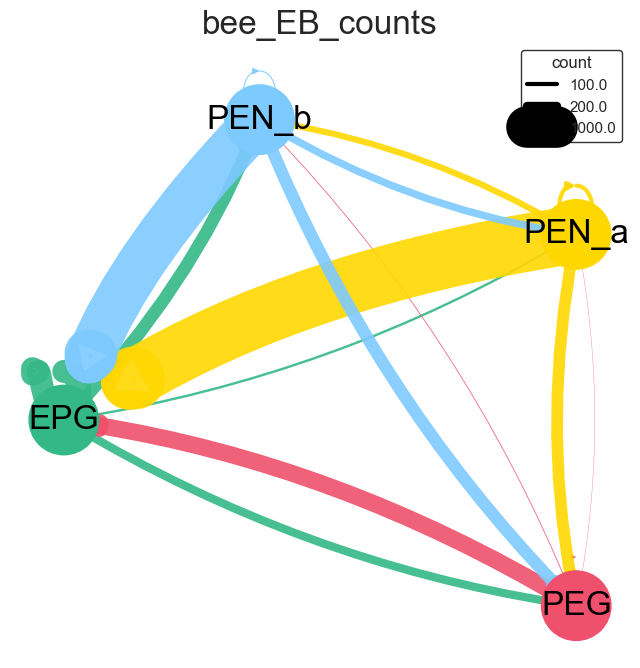

Plot saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\fly_EB_node_graph_counts.pdf


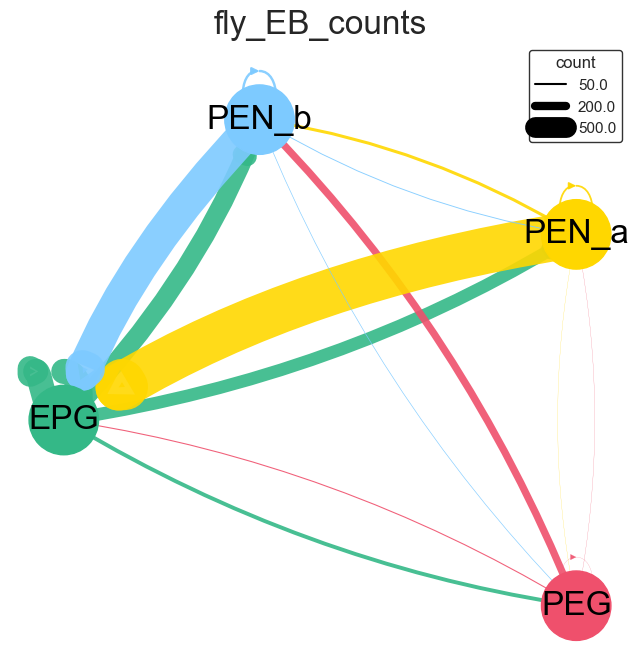

In [25]:
eb_core_bee_layout = {
    'EPG': [-1.00000000e+00, -8.74227766e-08],
    'EPGt': [-0.30901712, -0.95105648],
    'PEG': [ 0.80901724, -0.58778495],
    'PEN_a': [0.809017  , 0.58778524],
    'PEN_b': [-0.30901742,  0.95105636]
}

fc = eb_core_fly.copy()
fc = fc.replace({'EPGt': 'EPG'}, regex=True)
fg = fc.groupby(['type_pre', 'type_post'])['count'].sum().reset_index()

bc = eb_core_bee.copy()
bg = bc.groupby(['type_pre', 'type_post'])['count'].sum().reset_index()


fig_size=(8,8)


draw_connectivity_graph(bg, grouping='by_type', conn_type='count', node_layout=eb_core_bee_layout, figsize=fig_size,
                        width_multiplier=0.03, edge_alpha=0.9, color_dict=color_dict_type, title='bee_EB_counts', 
                        filename=f'bee_EB_node_graph_counts.pdf', sqrt_edges=False)

draw_connectivity_graph(fg, grouping='by_type', conn_type='count', node_layout=eb_core_bee_layout, figsize=fig_size,
                         width_multiplier=0.03, edge_alpha=0.9, color_dict=color_dict_type, title='fly_EB_counts', 
                         filename=f'fly_EB_node_graph_counts.pdf', sqrt_edges=False)


In [26]:
'''if the average number of synapses per neuron is under 3 for a given type,
that type is excluded
'''
fc = eb_core_fly.copy()
fc = fc.replace({'EPGt': 'EPG'}, regex=True)

# mean table
fg_mean = (
    fc.groupby(['type_pre', 'type_post'], as_index=False)['count']
    .mean()
    .rename(columns={'count': 'mean_count'})
)

# sum table
fg_sum = (
    fc.groupby(['type_pre', 'type_post'], as_index=False)['count']
    .sum()
    .rename(columns={'count': 'sum_count'})
)

# keep only connections with mean > 3
fg = (
    fg_sum.merge(fg_mean, on=['type_pre', 'type_post'])
    .query('mean_count > 3')
    .copy()
)

fg['sum_count'] = fg['sum_count'].astype(int)
fg = fg[['type_pre', 'type_post', 'sum_count']]
################################
bc = eb_core_bee.copy()

# mean table
bg_mean = (
    bc.groupby(['type_pre', 'type_post'], as_index=False)['count']
    .mean()
    .rename(columns={'count': 'mean_count'})
)

# sum table
bg_sum = (
    bc.groupby(['type_pre', 'type_post'], as_index=False)['count']
    .sum()
    .rename(columns={'count': 'sum_count'})
)

# keep only connections with mean > 3
bg = (
    bg_sum.merge(bg_mean, on=['type_pre', 'type_post'])
    .query('mean_count > 3')
    .copy()
)

bg['sum_count'] = bg['sum_count'].astype(int)
bg = bg[['type_pre', 'type_post', 'sum_count']]

Saved: D:\Github\capsule-7474392\code\analysis\../../results/plots\fig3_eb_difference_05-09-26.pdf


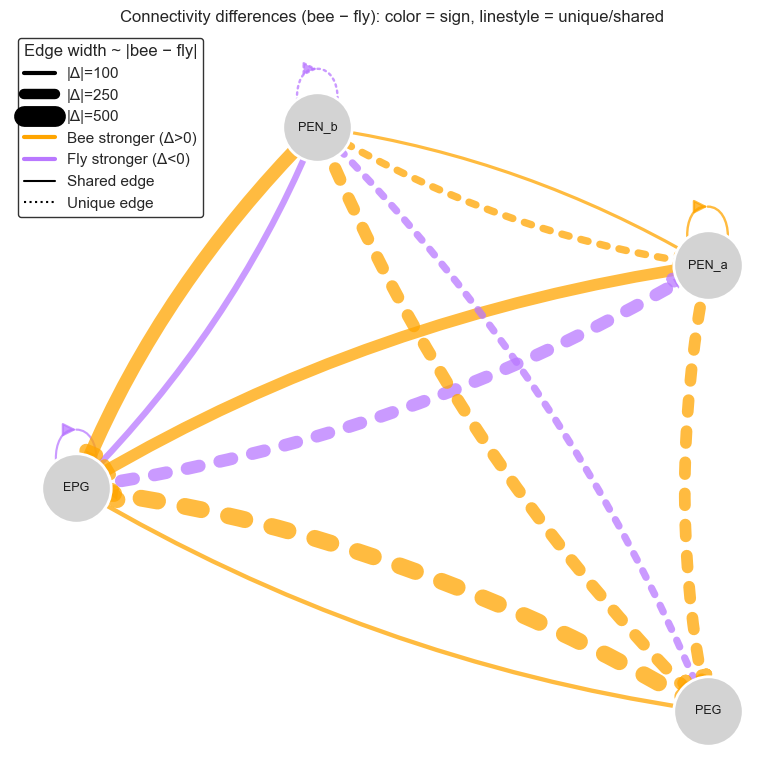

In [27]:
bee_connections = set(zip(bg['type_pre'], bg['type_post']))
fly_connections = set(zip(fg['type_pre'], fg['type_post']))

bee_only_connections = bee_connections - fly_connections
fly_only_connections = fly_connections - bee_connections
shared_connections   = bee_connections & fly_connections  


# Matrices + diff

bee_matrix = bg.pivot_table(index='type_pre', columns='type_post', values='sum_count', fill_value=0)
fly_matrix = fg.pivot_table(index='type_pre', columns='type_post', values='sum_count', fill_value=0)

all_pre_neurons  = sorted(set(bee_matrix.index).union(fly_matrix.index))
all_post_neurons = sorted(set(bee_matrix.columns).union(fly_matrix.columns))

bee_matrix = bee_matrix.reindex(index=all_pre_neurons, columns=all_post_neurons, fill_value=0)
fly_matrix = fly_matrix.reindex(index=all_pre_neurons, columns=all_post_neurons, fill_value=0)

diff_matrix = bee_matrix - fly_matrix  # bee - fly


# Graph from diff

G = nx.DiGraph()
for pre in diff_matrix.index:
    for post in diff_matrix.columns:
        val = diff_matrix.loc[pre, post]
        if val != 0:
            G.add_edge(pre, post, weight=float(val))


# Styling rules

width_multiplier = 0.03
bee_stronger_color = '#FFA500'  # orange
fly_stronger_color = '#b978ff'  # purple

def edge_color_from_weight(w):
    return bee_stronger_color if w > 0 else fly_stronger_color

def edge_style_from_presence(u, v):
    # dotted if unique to either species, solid if shared
    return 'dotted' if ((u, v) in bee_only_connections or (u, v) in fly_only_connections) else 'solid'

# Split edges into solid vs dotted for separate draw calls
solid_edges  = []
dotted_edges = []
for u, v in G.edges():
    if edge_style_from_presence(u, v) == 'solid':
        solid_edges.append((u, v))
    else:
        dotted_edges.append((u, v))

# Precompute widths/colors in matching order
solid_widths  = [abs(G[u][v]['weight']) * width_multiplier for u, v in solid_edges]
solid_colors  = [edge_color_from_weight(G[u][v]['weight']) for u, v in solid_edges]

dotted_widths = [abs(G[u][v]['weight']) * width_multiplier for u, v in dotted_edges]
dotted_colors = [edge_color_from_weight(G[u][v]['weight']) for u, v in dotted_edges]


# Plot

plt.figure(figsize=(8, 8), facecolor='white')

nx.draw_networkx_nodes(
    G, eb_core_bee_layout,
    node_size=2500,
    node_color='lightGrey',
    linewidths=2.0,
    edgecolors='white'
)
nx.draw_networkx_labels(G, eb_core_bee_layout, font_size=9)

# Shared (solid) edges
nx.draw_networkx_edges(
    G, eb_core_bee_layout,
    edgelist=solid_edges,
    edge_color=solid_colors,
    connectionstyle="arc3,rad=0.1",
    width=solid_widths,
    style='solid',
    arrowsize=20,
    alpha=0.75
)

# Unique (dotted) edges
nx.draw_networkx_edges(
    G, eb_core_bee_layout,
    edgelist=dotted_edges,
    edge_color=dotted_colors,
    connectionstyle="arc3,rad=0.1",
    width=dotted_widths,
    style='dotted',
    arrowsize=20,
    alpha=0.75
)


# Legend

example_abs_diffs = [100, 250, 500]  # pick values meaningful for  scale
legend_lines = [
    mlines.Line2D([], [], linewidth=w * width_multiplier, color='black', label=f'|Δ|={w}')
    for w in example_abs_diffs
]
legend_lines += [
    mlines.Line2D([], [], color=bee_stronger_color, linewidth=3, label='Bee stronger (Δ>0)'),
    mlines.Line2D([], [], color=fly_stronger_color, linewidth=3, label='Fly stronger (Δ<0)'),
    mlines.Line2D([], [], linestyle='solid',  color='black', label='Shared edge'),
    mlines.Line2D([], [], linestyle='dotted', color='black', label='Unique edge'),
]

plt.legend(
    handles=legend_lines,
    title="Edge width ~ |bee − fly|",
    loc="upper left",
    frameon=True,
    edgecolor="black",
    facecolor="white"
)

plt.title("Connectivity differences (bee − fly): color = sign, linestyle = unique/shared")
plt.axis('off')
plt.tight_layout()

fig_name = f"fig3_eb_difference_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)

plt.savefig(
    file_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0
)

print(f"Saved: {file_path}")
plt.show()
